In [1]:
from datetime import datetime
from io import StringIO
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
import tqdm
from matplotlib.lines import Line2D
from omegaconf import OmegaConf
from scipy.stats import spearmanr
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from estuary.model.config import EstuaryConfig
from estuary.model.data import create_splits
from estuary.util.img import false_color, normalized_image_3_channel

In [2]:
FIGURE_ROOT = Path("/Users/kyledorman/data/estuary/display/final_paper_figures")
OFFICIAL_FIG_DIR = FIGURE_ROOT / "official_submission"
PAPER_FIG_DIR = FIGURE_ROOT / "paper_draft_png"
for _dir in (OFFICIAL_FIG_DIR, PAPER_FIG_DIR):
    _dir.mkdir(exist_ok=True, parents=True)

# Existing figure cells save submission-quality files through SAVE_DIR.
# A patched savefig also writes Google-Docs-friendly PNG copies to PAPER_DIR.
SAVE_DIR = OFFICIAL_FIG_DIR
PAPER_DIR = PAPER_FIG_DIR

BASE = Path("/Volumes/x10pro/estuary/")

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.5,
        "legend.title_fontsize": 7.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

from matplotlib.figure import Figure

PAPER_COPY_FORMATS = {".pdf", ".tif", ".tiff", ".png", ".jpg", ".jpeg"}
PAPER_COPY_DPI = 250

if not hasattr(Figure, "_estuary_original_savefig"):
    Figure._estuary_original_savefig = Figure.savefig


def _savefig_with_paper_copy(self, fname, *args, **kwargs):
    result = Figure._estuary_original_savefig(self, fname, *args, **kwargs)

    if isinstance(fname, (str, Path)):
        path = Path(fname)
        if (
            path.suffix.lower() in PAPER_COPY_FORMATS
            and path.resolve().parent == OFFICIAL_FIG_DIR.resolve()
        ):
            paper_path = PAPER_DIR / f"{path.stem}.png"
            paper_kwargs = dict(kwargs)
            paper_kwargs["format"] = "png"
            paper_kwargs["dpi"] = paper_kwargs.get("dpi", PAPER_COPY_DPI)
            Figure._estuary_original_savefig(self, paper_path, *args, **paper_kwargs)

    return result


Figure.savefig = _savefig_with_paper_copy

In [3]:
gdf = gpd.read_file(BASE / "geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf.rename(columns={"Site code": "region"})
gdf = gdf[~gdf.skipped].copy()
gdf = gdf.set_index("region")

gdf_points = gdf.copy()
gdf_points.geometry = gdf.to_crs("ESRI:54008").geometry.centroid.to_crs(gdf.crs)

gdf.head(2)

,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,...,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry
region,,,,,,,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,...,SC-LPL,32.933,-117.260,32.931536,-117.256714,NaN,NaN,NaN,NaN,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,...,SC-ZUM,34.015,-118.821,34.014565,-118.820618,NaN,NaN,NaN,NaN,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."


In [4]:
ss_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat/labels.csv")
ss_df = ss_df[ss_df.region.isin(gdf.index)].copy()
ss_df = ss_df[ss_df.label != "unsure"].copy()
ss_df["acquired"] = pd.to_datetime(ss_df["acquired"], errors="coerce", utc=True)

ssw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat_water/labels.csv")
ssw_df = ssw_df[ssw_df.region.isin(gdf.index)].copy()
ssw_df = ssw_df[ssw_df.label != "unsure"].copy()
ssw_df["acquired"] = pd.to_datetime(ssw_df["acquired"], errors="coerce", utc=True)

ss_df.head(2)

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-20 17:07:34+00:00,skysat,2024,10,20241020_170734_ssc13_u0001
1,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-21 16:24:30+00:00,skysat,2024,10,20241021_162430_ssc4_u0001


In [5]:
d_df = pd.read_csv("/Users/kyledorman/data/estuary/dataset/train.csv")
d_df["acquired"] = pd.to_datetime(d_df["acquired"], errors="coerce", utc=True)
d_df = d_df[d_df.region.isin(gdf.index)].copy()


# ----------------------------
# Remap labels
# ----------------------------
def remap_label(x):
    x = str(x).strip().lower()
    mapping = {
        "closed": "closed",
        "perched open": "partial",
        "perched": "partial",
        "open": "open",
        "unsure": "low quality",
        "low quality": "low quality",
    }
    return mapping.get(x, x)


d_df["label_clean"] = d_df["label"].map(remap_label)

d_df.head(2)

,region,label,acquired,instrument,year,month,asset_id,source,source_tif,label_clean
0,11,open,2017-01-13 17:44:58+00:00,dove,2017,1,20170113_174458_0e0e,train,/Users/kyledorman/data/estuary/dataset/images/...,open
1,11,open,2017-02-01 17:46:04+00:00,dove,2017,2,20170201_174604_0e30,train,/Users/kyledorman/data/estuary/dataset/images/...,open


In [6]:
dw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_water/labels.csv")
dw_df = dw_df[dw_df.region.isin(gdf.index)].copy()
dw_df = dw_df[dw_df.label != "unsure"].copy()
dw_df["acquired"] = pd.to_datetime(dw_df["acquired"], errors="coerce", utc=True)

dw_df.head(2)

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,11,/Volumes/x10pro/estuary/sat_data/superdove/res...,open,2024-01-15 17:46:56+00:00,superdove,2024,1,20240115_174656_22_24c9
1,11,/Volumes/x10pro/estuary/sat_data/superdove/res...,open,2024-01-19 17:44:13+00:00,superdove,2024,1,20240119_174413_72_2423


In [7]:
ss_pairs = pd.merge(
    ss_df, ssw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)
dd_pairs = pd.merge(
    d_df, dw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)
dd_pairs = dd_pairs[dd_pairs.label_img != "unsure"].copy()

a = ss_df.sort_values("acquired").reset_index(drop=True)
b = d_df[d_df.label != "unsure"].sort_values("acquired").reset_index(drop=True)

# cross-join within region, then filter by window
tmp = pd.merge(
    a,
    b[["source_tif", "asset_id", "region", "label", "acquired"]],
    on="region",
    suffixes=("_ss", "_dd"),
)
tol = pd.Timedelta("10h")
tmp["time_diff"] = (tmp["acquired_dd"] - tmp["acquired_ss"]).abs()
mask = tmp["time_diff"] < tol
d_ss_pairs = tmp.loc[mask].sort_values(["region", "asset_id_ss", "asset_id_dd"])
d_ss_pairs = d_ss_pairs.drop_duplicates(["region", "asset_id_ss"])

print(len(d_ss_pairs))
d_ss_pairs.head(2)

324


,region,source_tif_ss,label_ss,acquired_ss,instrument,year,month,asset_id_ss,source_tif_dd,asset_id_dd,label_dd,acquired_dd,time_diff
25280,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2020-08-01 18:45:36+00:00,skysat,2020,8,20200801_184536_ssc1_u0002,/Users/kyledorman/data/estuary/dataset/images/...,20200801_161237_0f2e,open,2020-08-01 16:12:37+00:00,0 days 02:32:59
45851,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-11-10 21:35:51+00:00,skysat,2021,11,20211110_213551_ssc6_u0001,/Users/kyledorman/data/estuary/dataset/images/...,20211110_175344_57_227e,open,2021-11-10 17:53:44+00:00,0 days 03:42:07


In [8]:
non_merged_preds = pd.read_csv(
    "/Volumes/x10pro/results/estuary/train/20260305-095554/all_regions_timeseries_preds.csv"
)
print(len(non_merged_preds), (non_merged_preds.y_pred_unsure != 1).sum().item())

train_preds = pd.read_csv("/Volumes/x10pro/results/estuary/train/20260305-095554/train_preds.csv")
train_preds["label_clean"] = train_preds["orig_label"].map(remap_label)
print(len(train_preds), (train_preds.y_true != -1).sum().item())

preds_all_orig = pd.read_csv(
    "/Volumes/x10pro/results/estuary/train/20260305-095554/merged_all_regions_timeseries_preds.csv"
)

preds_all_orig["acquired"] = pd.to_datetime(preds_all_orig["acquired"], errors="coerce", utc=True)
preds_all_orig["date"] = preds_all_orig.acquired.dt.date
preds_all_orig["month"] = preds_all_orig.acquired.dt.month
preds_all_orig["year"] = preds_all_orig.acquired.dt.year
preds_all = preds_all_orig.copy()
preds_all = (
    preds_all[(preds_all.region.isin(gdf.index)) & (preds_all.y_pred_unsure != 1)]
    .copy()
    .sort_values(by=["region", "acquired"])
    .reset_index(drop=True)
)

preds_all.head(3)

98317 92487
12316 9742


,region,date,y_true,y_true_unsure,acquired,source_tif,y_pred_unsure,y_pred,p_closed,p_open,month,year
0,11,2017-02-01,1,0,2017-02-01 17:46:04+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.013752,0.986248,2,2017
1,11,2017-02-25,1,0,2017-02-25 17:46:40+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000013,0.999987,2,2017
2,11,2017-03-03,1,0,2017-03-03 17:47:32+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000008,0.999992,3,2017


In [9]:
ca = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_geo.geojson")
pmep_points = gpd.read_file("/Volumes/x10pro/estuary/geos/PMEP_Estuary_Points_V1_3.gdb/").to_crs(
    ca.crs
)

# Goleta Slough too close to San Pedro Creek, we see both!
pmep_points = pmep_points[pmep_points.PMEP_EstuaryID != 4003].copy()

pmep_points = pmep_points[pmep_points.intersects(ca.iloc[0].geometry)].copy()
print(len(pmep_points))
pmep_points.head(3)

189


/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry
253,2087,Smith River,PMEP,Riverine Estuary,"Washington, Oregon, Northern California Coast",120.0,481.289637,2087_Smith River,POINT Z (-124.18315 41.91363 0.00013)
254,2088,Lake Earl,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",121.0,1609.386192,2088_Lake Earl,POINT Z (-124.19721 41.82226 0.00013)
255,2089,Pebble Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",122.0,14.537437,2089_Pebble Beach,POINT Z (-124.22426 41.76496 0.00013)


In [10]:
gdf_plot = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf_plot = gdf_plot[gdf_plot.skipped == False].copy()
gdf_plot["in_dataset"] = True

joined = pmep_points.join(
    gdf_plot[
        ["PMEP_EstuaryID", "in_dataset", "Site name", "point_geom_lat", "point_geom_long"]
    ].set_index("PMEP_EstuaryID"),
    on="PMEP_EstuaryID",
    how="outer",
)

# 1. fill in_dataset
joined["in_dataset"] = joined["in_dataset"].fillna(False)

# 2. build geometry for rows missing PMEP_EstuaryID
mask = joined["PMEP_EstuaryID"].isna()

joined.loc[mask, "CMECS_Class"] = "Lagoonal Estuary"

joined.loc[mask, "geometry"] = gpd.points_from_xy(
    joined.loc[mask, "point_geom_long"], joined.loc[mask, "point_geom_lat"]
)

joined.loc[mask, "Estuary_Name"] = joined.loc[mask, "Site name"]

joined.loc[mask, "Estuary_Hectares"] = 50.0

# 3. drop temporary columns
joined = joined.drop(columns=["point_geom_lat", "point_geom_long", "Site name"])

# 4. ensure it's still a GeoDataFrame
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=pmep_points.crs)

joined.head()

,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry,in_dataset
253.0,2087.0,Smith River,PMEP,Riverine Estuary,"Washington, Oregon, Northern California Coast",120.0,481.289637,2087_Smith River,POINT Z (-124.18315 41.91363 0.00013),False
254.0,2088.0,Lake Earl,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",121.0,1609.386192,2088_Lake Earl,POINT Z (-124.19721 41.82226 0.00013),True
255.0,2089.0,Pebble Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",122.0,14.537437,2089_Pebble Beach,POINT Z (-124.22426 41.76496 0.00013),False
256.0,2090.0,Crescent City Harbor,PMEP,Embayment/Bay,"Washington, Oregon, Northern California Coast",123.0,188.965914,2090_Crescent City Harbor,POINT Z (-124.19052 41.74395 0.00013),False
257.0,2091.0,NC9 Cresent Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",124.0,7.051772,2091_NC9 Cresent Beach,POINT Z (-124.15027 41.72553 0.00013),False


/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


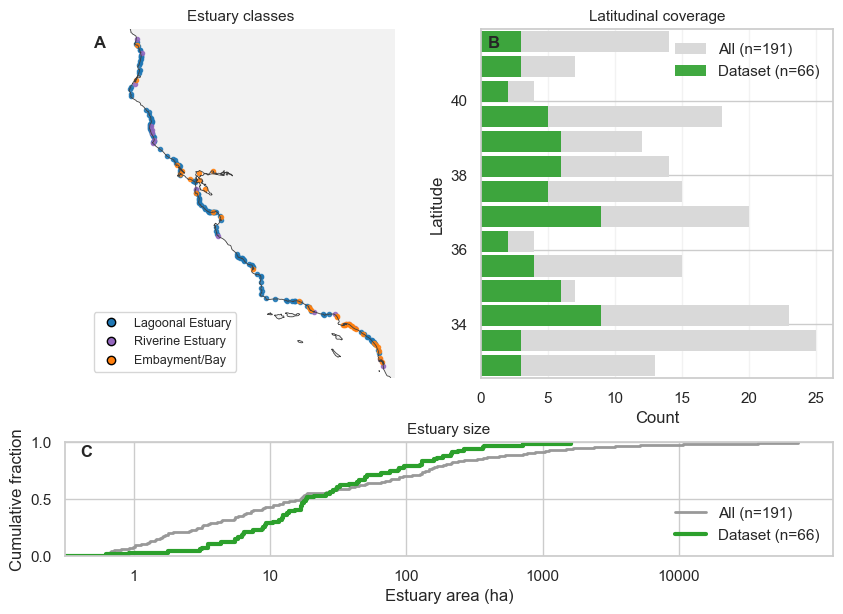

In [11]:
def make_opening_figure(joined):
    # --- prep ---
    df = joined.copy()
    df = df[df.geometry.notna()].copy()
    df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)
    df["CMECS_Class"] = df["CMECS_Class"].fillna("Unknown")

    # Use lagoonal-only for strip+ECDF if you want (recommended for your story)
    # df_lag = df[df["CMECS_Class"] == "Lagoonal Estuary"].copy()
    df_lag = df

    sns.set_theme(style="whitegrid")

    # Map classes (keep legend manageable)
    classes = ["Lagoonal Estuary", "Riverine Estuary", "Embayment/Bay", "Unknown"]
    classes = [c for c in classes if (df["CMECS_Class"] == c).any()]

    palette = {
        "Lagoonal Estuary": "#1f77b4",  # blue
        "Riverine Estuary": "#9467bd",  # purple
        "Embayment/Bay": "#ff7f0e",  # orange
        "Unknown": "0.6",
    }

    COLOR_ALL = "0.6"
    COLOR_DS = "#2ca02c"

    # --- layout you requested ---
    fig = plt.figure(figsize=(8, 6.2))

    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        height_ratios=[1.0, 1.0, 0.8],  # bottom row shorter (ECDF)
        width_ratios=[1.0, 1.0],  # right column narrower (strip)
        wspace=0.18,
        hspace=0.48,
    )

    ax_map = fig.add_subplot(gs[0:2, 0], projection=ccrs.PlateCarree())
    ax_ecdf = fig.add_subplot(gs[2, 0:2])
    ax_strip = fig.add_subplot(gs[0:2, 1])  # spans all rows

    # ----------------
    # Panel A: State map (ALL estuaries colored by CMECS)
    # ----------------
    minx, maxx = -125.6, -116.8
    miny, maxy = 32.2, 42.2
    proj = ccrs.PlateCarree()

    ax_map.set_extent([minx, maxx, miny, maxy], crs=proj)
    ax_map.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.95", edgecolor="none")
    ax_map.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
    ax_map.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6, color="0.25")
    ax_map.axis("off")
    # ax_map.set_title("All California estuaries (CMECS class)", fontsize=12)

    for cls in classes:
        g = df[df["CMECS_Class"] == cls]
        if g.empty:
            continue
        ax_map.scatter(
            g.geometry.x,
            g.geometry.y,
            s=9,
            color=palette.get(cls, "0.6"),
            alpha=0.85,
            transform=proj,
            # rasterized=True,
        )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=palette.get(cls, "0.6"),
            markersize=6,
            label=cls,
        )
        for cls in classes
    ]
    ax_map.legend(handles=handles, loc="lower left", frameon=True, fontsize=9)

    # ----------------
    # Panel B: Coastline coverage (latitude histogram)
    # ----------------
    df_lag = df_lag[df_lag.geometry.notna()].copy()
    df_lag["lat"] = df_lag.geometry.y

    lat_all = df_lag["lat"].to_numpy()
    lat_ds = df_lag.loc[df_lag["in_dataset"], "lat"].to_numpy()

    # Choose number of latitude bins (10–16 usually looks good)
    n_bins = 14
    bins = np.linspace(lat_all.min(), lat_all.max(), n_bins + 1)

    # Horizontal bars are easier in a tall/narrow panel
    counts_all, _ = np.histogram(lat_all, bins=bins)
    counts_ds, _ = np.histogram(lat_ds, bins=bins)

    bin_mids = 0.5 * (bins[:-1] + bins[1:])
    bin_h = (bins[1] - bins[0]) * 0.85

    ax_strip.barh(
        bin_mids,
        counts_all,
        height=bin_h,
        color="0.85",
        edgecolor="none",
        label=f"All (n={len(lat_all)})",
    )

    ax_strip.barh(
        bin_mids,
        counts_ds,
        height=bin_h,
        color=COLOR_DS,
        edgecolor="none",
        alpha=0.9,
        label=f"Dataset (n={len(lat_ds)})",
    )

    ax_strip.set_ylabel("Latitude")
    ax_strip.set_xlabel("Count")
    # ax_strip.set_title("Coastline coverage", fontsize=12)

    # Keep y-lims tight and nice
    ax_strip.set_ylim(lat_all.min(), lat_all.max())
    ax_strip.grid(axis="x", alpha=0.25)

    # Legend inside to avoid layout whitespace
    ax_strip.legend(loc="upper right", frameon=False)

    # ----------------
    # Panel C: ECDF size (ALL vs DATASET)
    # ----------------
    df_ecdf = df_lag[df_lag["Estuary_Hectares"].notna()].copy()

    sns.ecdfplot(
        data=df_ecdf,
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_ALL,
        lw=2,
        label=f"All (n={len(df_ecdf)})",
    )
    sns.ecdfplot(
        data=df_ecdf[df_ecdf["in_dataset"]],
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_DS,
        lw=3,
        label=f"Dataset (n={df_ecdf['in_dataset'].sum()})",
    )

    ax_ecdf.set_xscale("log")
    ax_ecdf.set_xlabel("Estuary area (ha)")
    ax_ecdf.set_ylabel("Cumulative fraction")
    # ax_ecdf.set_title("Estuary size distribution", fontsize=12)

    ticks = [1, 10, 100, 1000, 10000]
    ax_ecdf.set_xticks(ticks)
    ax_ecdf.set_xticklabels([str(t) for t in ticks])

    ax_map.set_title("Estuary classes", fontsize=11)
    ax_strip.set_title("Latitudinal coverage", fontsize=11)
    ax_ecdf.set_title("Estuary size", fontsize=11)

    for ax, label in [(ax_map, "A"), (ax_strip, "B"), (ax_ecdf, "C")]:
        ax.text(
            0.02,
            0.98,
            label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            fontweight="bold",
        )

    # Legend inside -> no extra whitespace
    ax_ecdf.legend(loc="lower right", frameon=False, ncol=1)

    fig.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.10)
    return fig


# Usage:
fig = make_opening_figure(joined)

fig.savefig(
    SAVE_DIR / "fig01_dataset_ca_coverage.pdf",
    bbox_inches="tight",
    pad_inches=0.09,
    dpi=300,
)

plt.show()

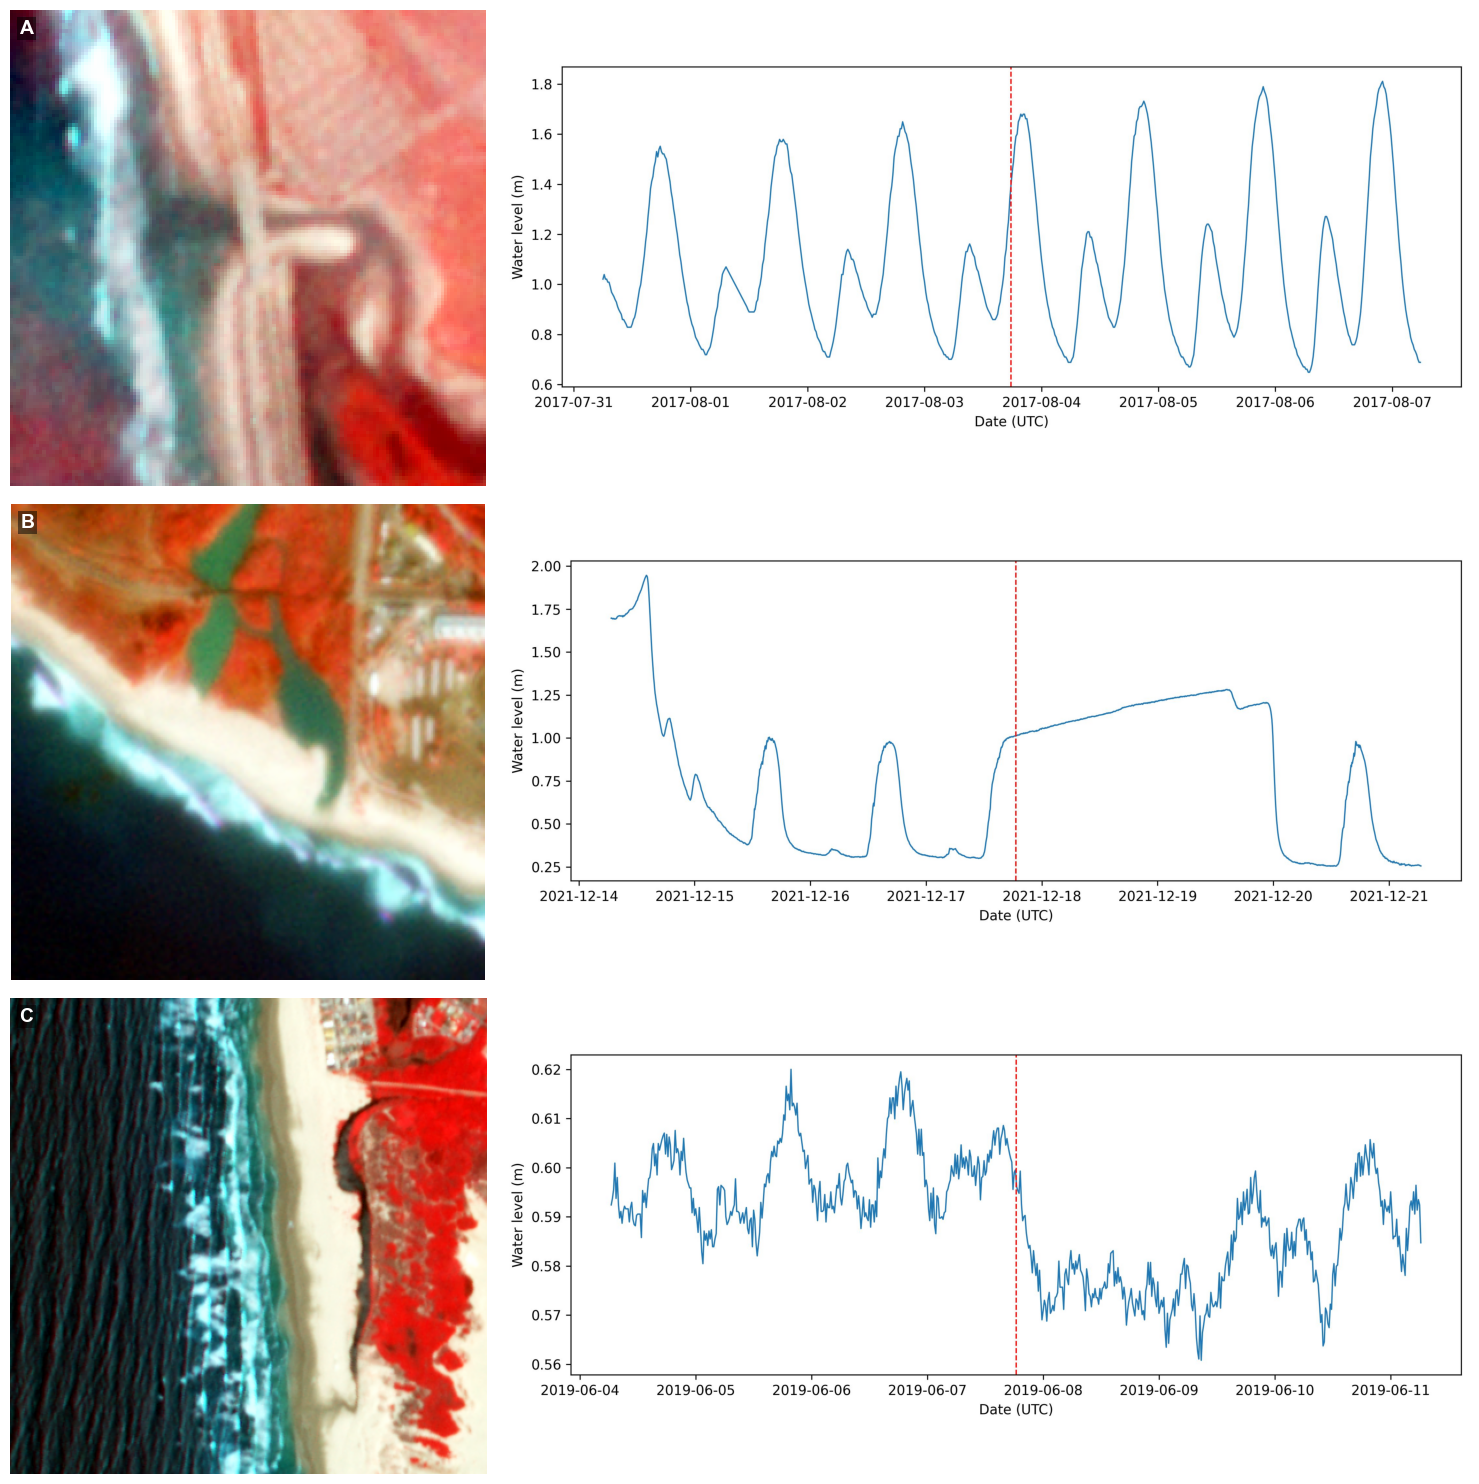

In [30]:
from scripts.display.generate_submission_figures import figure_2

figure_2(SAVE_DIR, FIGURE_ROOT / "water_plots")

In [13]:
preds_test = train_preds[(train_preds.year == 2025) & (train_preds.y_true >= 0)]

# -----------------------------
# Binary entropy
# -----------------------------
p = preds_test["p_open"].values
entropy = -(p * np.log(p + 1e-12) + (1 - p) * np.log(1 - p + 1e-12))

preds_test = preds_test.copy()
preds_test["entropy"] = entropy


rows = []

for label, df in preds_test.groupby("label_clean"):
    pred_closed_rate = (df["y_pred"] == 0).mean()
    pred_open_rate = (df["y_pred"] == 1).mean()

    i = 0 if label == "closed" else 1
    f1 = f1_score(df.y_true == i, df.y_pred == i)

    q1 = df["entropy"].quantile(0.25)
    q3 = df["entropy"].quantile(0.75)

    rows.append(
        {
            "Original class": label.capitalize(),
            "F1": round(f1, 2),
            # "Pred Closed": round(pred_closed_rate, 2),
            "Open %": round(pred_open_rate, 2),
            "Mean Entropy": round(df["entropy"].mean(), 2),
            "N": len(df),
        }
    )

table2 = pd.DataFrame(rows)

# -----------------------------
# Plot table
# -----------------------------
table2 = pd.DataFrame(rows)

# Optional: force a stable row order
class_order = ["Closed", "Open", "Partial", "Perched"]
table2["Original class"] = pd.Categorical(
    table2["Original class"],
    categories=class_order,
    ordered=True,
)
table2 = table2.sort_values("Original class").reset_index(drop=True)

# Cleaner column names for manuscript table
table2 = table2.rename(
    columns={
        "F1": "F1 score",
        "Open %": "Predicted open fraction",
        "Mean Entropy": "Mean entropy",
    }
)

# Save source-of-truth table
table2.to_csv(SAVE_DIR / "table2_model_performance.csv", index=False)

# Save copy-pasteable editable table for Google Docs
html = table2.to_html(index=False, border=0)

html_doc = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8">
<style>
  body {{
    font-family: Arial, sans-serif;
    margin: 24px;
  }}
  table {{
    border-collapse: collapse;
    font-size: 11pt;
  }}
  th, td {{
    border: 1px solid #999;
    padding: 6px 8px;
    text-align: left;
    vertical-align: top;
  }}
  th {{
    font-weight: bold;
    background: #f2f2f2;
  }}
  td:not(:first-child), th:not(:first-child) {{
    text-align: right;
  }}
</style>
</head>
<body>
{html}
</body>
</html>
"""

(PAPER_DIR / "table2_model_performance.html").write_text(html_doc)

1100

In [14]:
OPEN_THRESHOLD = 0.440

# 1) Make sure date is datetime64[ns]
df = preds_all.copy()
df["date"] = pd.to_datetime(df["date"])

# 2) Get global date range
start = datetime(year=2018, month=1, day=1)
# df["date"].min()
end = df["date"].max()

# 3) Build full MultiIndex: all regions × all dates
regions = df["region"].unique()
full_dates = pd.date_range(start, end, freq="D")

full_index = pd.MultiIndex.from_product(
    [regions, full_dates],
    names=["region", "date"],
)

# 4) Reindex and forward-fill within each region
full = df.set_index(["region", "date"]).sort_index().reindex(full_index)

# Forward-fill predictions within each region
full["y_pred"] = full["y_pred"].groupby(level="region").ffill()

prob_cols = ["p_closed", "p_open"]

for key in prob_cols:
    # Forward-fill predictions within each region
    full[key] = (
        full[key]
        .groupby(level="region")
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
        .ffill()
        .reset_index(level=0, drop=True)
    )

# normalize
P = full[prob_cols].to_numpy(dtype=float)
row_sum = np.nansum(P, axis=1, keepdims=True)

# Only normalize rows with valid positive mass
ok = np.isfinite(row_sum[:, 0]) & (row_sum[:, 0] > 0)
P_norm = P.copy()
P_norm[ok] = P[ok] / row_sum[ok]

# Write back
full.loc[:, prob_cols] = P_norm

region_min_date = df.groupby("region").date.min().max()
region_max_date = df.groupby("region").date.max().min()

full = full.reset_index()
full = full[full.date.between(region_min_date, region_max_date)].copy()
full = full.set_index(["region", "date"])

date_axis = full["p_open"].unstack("date").columns.to_list()
region_labels = full["p_open"].unstack("date").index.to_list()

probs = full[prob_cols].to_numpy(dtype=float)

y_pred = (full["p_open"] > OPEN_THRESHOLD).astype(int)

full["y_pred"] = y_pred

# Entropy
eps = 1e-12
P_clip = np.clip(probs, eps, 1.0)

entropy = -np.sum(P_clip * np.log(P_clip), axis=1)

# Normalize by log(K)
K = len(prob_cols)
entropy_norm = entropy / np.log(K)

# Add to full DataFrame
full["entropy"] = entropy
full["entropy_norm"] = entropy_norm

In [15]:
tidal_data = np.load("/Volumes/x10pro/estuary/geos/region_tide_heights.npz", allow_pickle=True)
tide_minutes = tidal_data["minutes"]
tide_minutes = pd.to_datetime(tide_minutes, utc=True)
tidal_sites = list(map(int, tidal_data["site_ids"].tolist()))


def region_tidal_data(region, start, end):
    idx = tidal_sites.index(region)
    tide_df = (
        pd.DataFrame(
            {
                "timestamp_utc": pd.to_datetime(tide_minutes, utc=True),
                "tide_height": tidal_data["elev"][idx],
            }
        )
        .set_index("timestamp_utc")
        .sort_index()
    )

    return tide_df.loc[start:end].reset_index()


list(tidal_data.keys())

['elev',
 'minutes',
 'site_ids',
 'x',
 'y',
 'model_name',
 'model_format',
 'step_minutes']

In [16]:
def filter_outliers(df: pd.DataFrame, depth_col: str = "height") -> pd.DataFrame:
    # Quick-and-dirty outlier removal on depth values using IQR
    y = df[depth_col].astype(float)
    q1 = y.quantile(0.25)
    q3 = y.quantile(0.75)
    iqr = q3 - q1

    # Keep points within 3 * IQR (lenient to preserve events)
    lo = q1 - 3 * iqr
    hi = q3 + 3 * iqr

    mask = (y >= lo) & (y <= hi)
    return df.loc[mask].copy()


def contiguous_segments(
    df: pd.DataFrame, time_col: str = "acquired", gap_hours: int = 48
) -> list[pd.DataFrame]:
    """
    Find all contiguous segments in a time series (gaps > gap_hours separate segments).
    """
    out = []

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.dropna(subset=[time_col]).sort_values(time_col)
    if df.empty:
        return []

    gap = pd.Timedelta(hours=gap_hours)
    seg_id = (df[time_col].diff() > gap).cumsum()
    # Find all segments
    for sid in seg_id.unique():
        seg = df[seg_id == sid]

        if seg.empty:
            continue

        seg = filter_outliers(seg.copy())
        out.append(seg.reset_index(drop=True))

    return out


def subsample_time(df, resample_amount: str = "30min", columns: list[str] | None = None):
    df["timestamp_utc"] = pd.to_datetime(
        df["timestamp_utc"],
        utc=True,
        errors="coerce",
    )
    df = df.dropna(subset=["timestamp_utc"])
    if columns is not None:
        columns.append("timestamp_utc")
        df = df[columns]
    return (
        df.set_index("timestamp_utc")
        .sort_index()
        .resample(resample_amount, origin="epoch")
        .median()  # or .median(), .first(), etc.
        .dropna()
        .reset_index()
    )


def inlet_only_tidal_attenuation(
    s: pd.Series,
    *,
    window_days: int = 3,
    tz: str = "UTC",
) -> pd.DataFrame:
    """
    Inlet-only tidal attenuation (suppression index).

    Returns DataFrame with:
        - daily_range
        - tidal_range_proxy (rolling min of daily_range)
        - attenuation_pct
    """

    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("Series must have DatetimeIndex")

    s = s.copy()

    s = s.sort_index().dropna()

    # Daily min/max
    daily = s.resample("1D").agg(["min", "max"])
    daily.columns = ["daily_min", "daily_max"]

    # Daily range
    daily["daily_range"] = daily["daily_max"] - daily["daily_min"]

    # Rolling minimum (tidal proxy)
    daily["tidal_range_proxy"] = (
        daily["daily_range"].rolling(window_days, min_periods=1, center=True).min()
    )

    return daily


def calc_tidal_attenuation(
    s: pd.Series,
    o: pd.Series,
    *,
    window_days: int = 3,
) -> pd.DataFrame:
    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("Series must have DatetimeIndex")
    if not isinstance(o.index, pd.DatetimeIndex):
        raise TypeError("Series must have DatetimeIndex")

    s = s.sort_index().dropna()
    o = o.sort_index().dropna()

    # Daily min/max + range (peak-to-trough)
    sd = s.resample("1D").agg(["min", "max"])
    sd.columns = ["s_daily_min", "s_daily_max"]
    sd["s_daily_range"] = sd["s_daily_max"] - sd["s_daily_min"]

    od = o.resample("1D").agg(["min", "max"])
    od.columns = ["o_daily_min", "o_daily_max"]
    od["o_daily_range"] = od["o_daily_max"] - od["o_daily_min"]

    # Rolling min range
    s_range = sd["s_daily_range"].rolling(window_days, min_periods=1, center=True).min()

    # Align indices (in case s/o cover different date spans)
    s_range, o_range = s_range.align(od["o_daily_range"], join="inner")

    ratio = s_range / np.maximum(eps, o_range)

    out = pd.DataFrame(index=s_range.index)
    out["estuery_daily_range"] = s_range
    out["tide_daily_range"] = o_range
    out["tidal_ratio"] = ratio.clip(lower=0.0, upper=1.0)
    out["tidal_attenuation"] = 1 - out["tidal_ratio"]

    return out

In [17]:
water_data_path = Path("/Volumes/x10pro/estuary/water_data/processed/")

all_segments = {}
subsample = "30min"
max_gap = 8


def get_region_tide_series(sdf: pd.DataFrame, region, subsample) -> pd.Series:
    ocean = region_tidal_data(region, sdf.index.min(), sdf.index.max())
    ocean = ocean.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc")
    ocean = subsample_time(ocean, subsample, ["tide_height"])
    return ocean.set_index("timestamp_utc")["tide_height"]


for region, _ in tqdm.tqdm(gdf.iterrows(), total=len(gdf)):
    region_water_data_dir = water_data_path / str(region)
    if not region_water_data_dir.exists():
        continue

    region_segments = []
    for p in region_water_data_dir.glob("*.csv"):
        df = pd.read_csv(p, dtype={"sensor_id": "string", "source": "string"})
        for _, sdf in df.groupby(["sensor_id", "source"]):
            segments = contiguous_segments(sdf, time_col="timestamp_utc", gap_hours=max_gap)
            segments = [subsample_time(seg, subsample, ["height"]) for seg in segments]
            region_segments.extend(segments)

    if len(region_segments) == 0:
        continue

    region_segments = sorted(
        region_segments,
        key=lambda sdf: sdf.timestamp_utc.max() - sdf.timestamp_utc.min(),
        reverse=True,
    )

    all_median = pd.concat(
        [subsample_time(s, subsample, ["height"]) for s in region_segments]
    ).height.median()
    meds = [s.height.median() for s in region_segments]
    keep = [np.abs(m - all_median) < 3 for m in meds]
    region_segments = [s for s, k in zip(region_segments, keep) if k]

    seg = pd.concat(region_segments)
    df = seg.drop_duplicates("timestamp_utc").sort_values("timestamp_utc")

    # parse timestamps + set index (UTC)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp_utc"])
    df = df.set_index("timestamp_utc").sort_index()

    # z-score (if you want it)
    df["height_z"] = (df["height"] - df["height"].mean()) / df["height"].std()

    region_segments = contiguous_segments(
        df.reset_index(), time_col="timestamp_utc", gap_hours=max_gap
    )
    region_segments = [
        s
        for s in region_segments
        if (s.timestamp_utc.max() - s.timestamp_utc.min()) > pd.Timedelta("7D")
    ]

    out_segments = []
    for sdf in region_segments:
        sdf = sdf.set_index("timestamp_utc")
        s = sdf.height
        tide = get_region_tide_series(s, region, subsample)

        tidal_attn = calc_tidal_attenuation(s, tide, window_days=5)
        tidal_hf = tidal_attn.reindex(sdf.index, method="ffill")

        # m12 = rolling_tidal_spectral_metrics_welch(
        #     s,
        #     band_hours=(10, 14),
        # )

        # m24 = rolling_tidal_spectral_metrics_welch(
        #     s,
        #     band_hours=(20, 28),
        # )

        # tp_total = m12.tp_frac + m24.tp_frac
        # tp_hf = tp_total.reindex(sdf.index, method="ffill")

        # tidal_attn_prox = inlet_only_tidal_attenuation(s)
        # tidal_prox_hf = tidal_attn_prox.reindex(sdf.index, method="ffill")

        # merge
        sdf["tide"] = tide.reindex(sdf.index)
        df2 = sdf.join(tidal_hf)
        # df3 = df2.join(tidal_hf)
        # df4 = df3.join(tidal_prox_hf)
        df4 = df2.reset_index().sort_values("timestamp_utc")
        out_segments.append(df4)

    all_segments[region] = out_segments

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 66/66 [00:24<00:00,  2.72it/s]


In [18]:
targets = full.index.to_frame(index=False).copy()
targets["date"] = pd.to_datetime(targets["date"]).astype("datetime64[ns]")

VALUE_COL = "height"
TS_COL = "timestamp_utc"
TOL = "1h"

colors = {
    1: "tab:blue",
    0: "tab:orange",
}

for val_col in ["height", "height_z", "tidal_attenuation", "tide"]:
    # We'll fill this
    targets[val_col] = pd.NA

    # Now fill targets region by region
    for region, g in tqdm.tqdm(
        targets.groupby("region", sort=False), total=len(targets.region.unique())
    ):
        if region not in all_segments:
            continue

        # Work on a view we can update, then write back
        idx = g.index
        need = targets.loc[idx, val_col].isna()
        if not need.any():
            continue

        # Each segment corresponds to ONE logger for some contiguous interval.
        # We’ll try them in priority order and fill the first that overlaps.
        for seg in all_segments[region]:
            # s = seg.sort_values(TS_COL).set_index(TS_COL).resample("1D", origin="epoch").mean()
            # s.index = s.index.date
            # s.index = pd.to_datetime(s.index, errors="coerce")

            seg_i = seg.copy()
            seg_i[TS_COL] = pd.to_datetime(seg_i[TS_COL], utc=True).dt.tz_convert(None)

            s = seg_i.sort_values(TS_COL).set_index(TS_COL).resample("1D").mean(numeric_only=True)

            s.index = s.index.normalize().astype("datetime64[ns]")

            # Segment coverage interval
            seg_start = pd.Timestamp(s.index.min())
            seg_end = pd.Timestamp(s.index.max())

            # Which target rows still need filling AND are within this segment’s time span?
            need = targets.loc[idx, val_col].isna()
            if not need.any():
                break

            in_range = (
                need
                & (targets.loc[idx, "date"] >= seg_start)
                & (targets.loc[idx, "date"] <= seg_end)
            )
            if not in_range.any():
                continue

            # Indices of target rows we want to fill for this segment
            in_range_idx = idx[in_range]  # original targets indices (not 0..n)

            # Build left table and carry original row index explicitly
            left = targets.loc[in_range_idx, ["date"]].copy()
            left["_row"] = left.index
            left["date"] = pd.to_datetime(left["date"]).astype("datetime64[ns]")
            left = left.sort_values("date")

            matched = pd.merge_asof(
                left,
                s[val_col],
                left_on="date",
                right_index=True,
                direction="nearest",
                # tolerance=TOL,
            )

            got = matched[val_col].notna()
            if got.any():
                rows_to_fill = matched.loc[got, "_row"].to_numpy()
                vals_to_fill = matched.loc[got, val_col].to_numpy()

                targets.loc[rows_to_fill, val_col] = vals_to_fill

    full[val_col] = targets[val_col].to_numpy()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 66/66 [00:00<00:00, 131.71it/s]


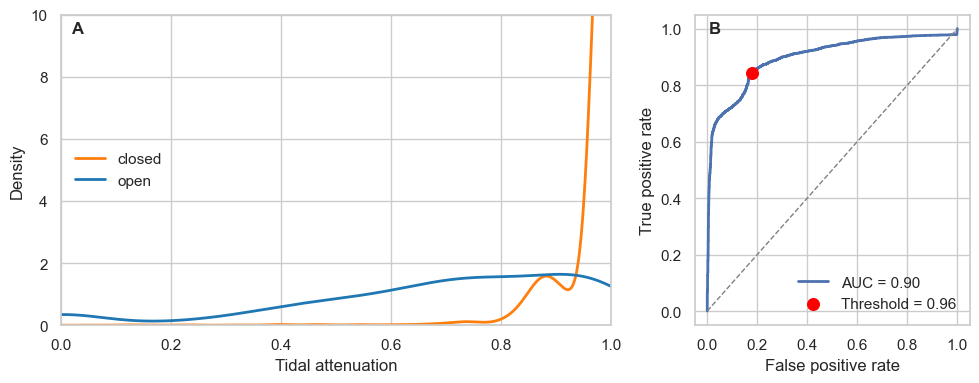

In [19]:
# -----------------------------------
# Prepare data
# -----------------------------------
df = full[full["height"].notna() & full["source_tif"].notna()].copy()

y_true = df["y_pred"].to_numpy()
score = 1.0 - df["tidal_attenuation"].astype(np.float32).to_numpy()  # higher = more open

# -----------------------------------
# ROC curve + AUC
# -----------------------------------
fpr, tpr, _ = roc_curve(y_true, score)
auc = roc_auc_score(y_true, score)
thresh = 0.96

# rule: open if tidal_attenuation < thresh
y_pred_rule = (df["tidal_attenuation"].to_numpy() < thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_rule).ravel()
fpr_point = fp / (fp + tn)
tpr_point = tp / (tp + fn)

# -----------------------------------
# Plot setup
# -----------------------------------
K = [0, 1]
label_map = {0: "closed", 1: "open"}
colors = {
    1: "tab:blue",
    0: "tab:orange",
}

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    gridspec_kw={"width_ratios": [2, 1]},
)

# -----------------------------------
# Left panel: tidal attenuation density by predicted class
# -----------------------------------
for k in K:
    s_all = df.loc[df["y_pred"] == k, "tidal_attenuation"].dropna()
    s_all.plot(
        kind="kde",
        ax=ax_left,
        color=colors[k],
        label=label_map[k],
        linewidth=2,
        bw_method=0.3,
        ind=np.linspace(0, 1, 1000),
    )

# ax_left.set_title("Tidal Attenuation by Predicted Class")
ax_left.set_xlabel("Tidal attenuation")
ax_left.set_ylabel("Density")
ax_left.legend(frameon=False)
ax_left.set_xlim(0, 1)
ax_left.set_ylim(0, 10)

# -----------------------------------
# Right panel: ROC curve
# -----------------------------------
ax_right.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.2f}")
ax_right.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

ax_right.scatter(
    fpr_point,
    tpr_point,
    color="red",
    s=70,
    zorder=3,
    label=f"Threshold = {thresh:.2f}",
)

# ax_right.set_xlabel("False Positive Rate")
# ax_right.set_ylabel("True Positive Rate")
# ax_right.set_title("ROC Curve")
ax_right.legend(loc="lower right", frameon=False)

ax_left.text(
    0.02,
    0.98,
    "A",
    transform=ax_left.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    fontweight="bold",
)

ax_right.text(
    0.05,
    0.98,
    "B",
    transform=ax_right.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    fontweight="bold",
)

ax_left.set_xlabel("Tidal attenuation")
ax_right.set_xlabel("False positive rate")
ax_right.set_ylabel("True positive rate")

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "fig03_tidal_attn_and_roc_combined.pdf",
    bbox_inches="tight",
    pad_inches=0.15,
)

plt.show()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_86107/2870344716.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  g0["point_geom_lat"] = g0.geometry.centroid.y


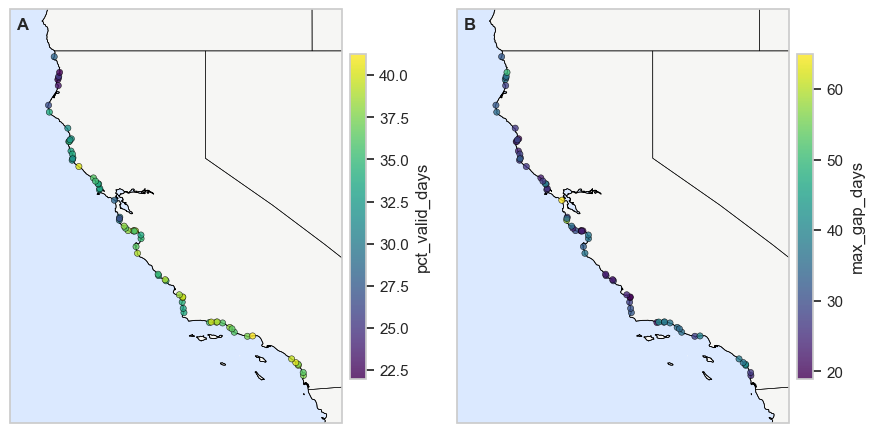

In [20]:
from scripts.display.generate_submission_figures import figure_4

figure_4(gdf_points, preds_all, SAVE_DIR)

"""Legacy inline implementation retained for provenance.
df = preds_all.copy()

samples_per_site = df.groupby("region").size().rename("n_samples")

start = datetime(year=2018, month=1, day=1, tzinfo=UTC)
end = df["acquired"].max().normalize()
all_days = pd.date_range(start, end, freq="D")
df = df[df.acquired > start]
n_days_total = len(all_days)
days_per_site = df.assign(date=df["acquired"].dt.normalize()).groupby("region")["date"].nunique()

pct_days_per_site = 100 * days_per_site / n_days_total


def max_gap_days(times: pd.Series) -> float:
    times = times.sort_values()
    gaps = times.diff().dt.days.dropna()
    return gaps.max() if len(gaps) else 0


max_gap_per_site = df.groupby("region")["acquired"].apply(max_gap_days).rename("max_gap_days")

g0 = (
    gdf_points.reset_index()[["region", "geometry"]]
    .set_index("region")
    .join(pct_days_per_site, how="left")
)
g1 = (
    gdf_points.reset_index()[["region", "geometry"]]
    .set_index("region")
    .join(max_gap_per_site, how="left")
)

g0["point_geom_lat"] = g0.geometry.centroid.y

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(9, 5),
    # constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

g0.rename(columns={"date": "pct_valid_days"}, inplace=True)

plot_estuaries_ca(
    g0,
    column="pct_valid_days",
    cmap="viridis",
    # title="A",
    add_colorbar=True,
    show=False,
    markersize=20,
    jitter_deg=0.01,
    point_alpha=0.8,
    # save_path=FIG_DIR / "state_map_pct_days_with_valid_sample.png",
    ax=axes[0],
)

plot_estuaries_ca(
    g1,
    column="max_gap_days",
    cmap="viridis",
    # title="B",
    add_colorbar=True,
    show=False,
    markersize=20,
    jitter_deg=0.01,
    point_alpha=0.8,
    # save_path=FIG_DIR / "state_map_gap.png",
    ax=axes[1],
)

axes[0].text(
    0.02,
    0.98,
    "A",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=12,
    fontweight="bold",
)

axes[1].text(
    0.02,
    0.98,
    "B",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=12,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "fig04_spatial_coverage_and_gaps.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=300,
)

plt.show()
"""

,year,average_gap_days,total_gap_days,median_gap_days,max_gap_days,n_gaps,n_sites
0,2018,2.76,22362.0,2.0,59.0,8090,66
1,2019,2.82,23970.0,2.0,37.0,8503,66
2,2020,2.61,24351.0,2.0,42.0,9334,66
3,2021,2.60,23895.0,2.0,28.0,9200,66
4,2022,2.78,23877.0,2.0,40.0,8574,66
5,2023,3.72,24214.0,2.0,65.0,6512,66
6,2024,2.98,24217.0,2.0,38.0,8137,66
7,2025,2.95,24176.0,2.0,36.0,8197,66


,month,month_name,average_gap_days,total_gap_days,median_gap_days,max_gap_days,n_gaps,n_sites
0,1,Jan,3.30,15775.0,2.0,42.0,4780,66
1,2,Feb,2.59,14635.0,2.0,28.0,5658,66
2,3,Mar,2.73,16604.0,2.0,32.0,6084,66
3,4,Apr,2.50,15500.0,2.0,27.0,6203,66
4,5,May,2.80,16077.0,2.0,27.0,5742,66
5,6,Jun,2.91,16061.0,2.0,43.0,5512,66
6,7,Jul,3.42,15185.0,2.0,65.0,4443,66
7,8,Aug,3.21,17687.0,2.0,40.0,5504,66
8,9,Sep,3.00,15782.0,2.0,33.0,5255,66
9,10,Oct,2.56,16845.0,2.0,39.0,6587,66


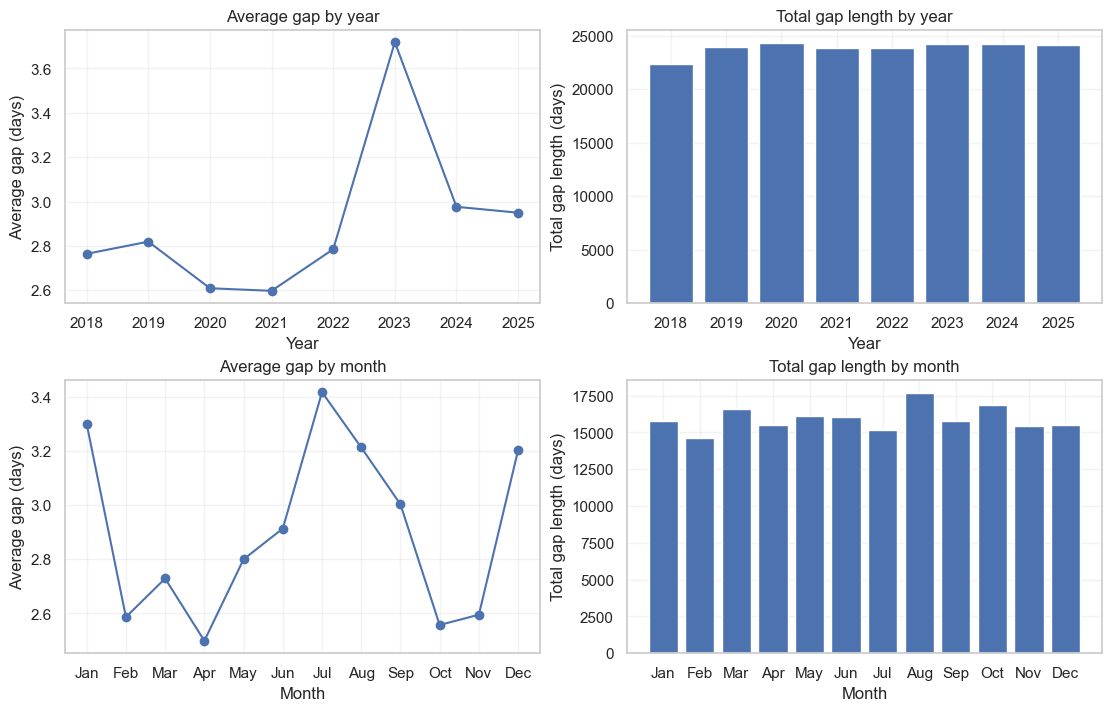

In [21]:
# Average and total inter-acquisition gap length by month and year

gap_df = preds_all[["region", "acquired"]].copy()
gap_df["acquired"] = pd.to_datetime(gap_df["acquired"], utc=True)

start = pd.Timestamp("2018-01-01", tz="UTC")
gap_df = gap_df[gap_df["acquired"] > start].copy()

# Use one observation per estuary per calendar day.
gap_df["date"] = gap_df["acquired"].dt.normalize()
gap_df = gap_df[["region", "date"]].drop_duplicates().sort_values(["region", "date"])

# Match the gap definition used in max_gap_days().
gap_df["gap_days"] = gap_df.groupby("region")["date"].diff().dt.days
gap_df = gap_df.dropna(subset=["gap_days"]).copy()

gap_df["year"] = gap_df["date"].dt.year
gap_df["month"] = gap_df["date"].dt.month
gap_df["month_name"] = gap_df["date"].dt.strftime("%b")

# Summary by calendar year.
gap_by_year = (
    gap_df.groupby("year")
    .agg(
        average_gap_days=("gap_days", "mean"),
        total_gap_days=("gap_days", "sum"),
        median_gap_days=("gap_days", "median"),
        max_gap_days=("gap_days", "max"),
        n_gaps=("gap_days", "size"),
        n_sites=("region", "nunique"),
    )
    .reset_index()
)

# Summary by month of year, pooled across all years.
gap_by_month = (
    gap_df.groupby(["month", "month_name"])
    .agg(
        average_gap_days=("gap_days", "mean"),
        total_gap_days=("gap_days", "sum"),
        median_gap_days=("gap_days", "median"),
        max_gap_days=("gap_days", "max"),
        n_gaps=("gap_days", "size"),
        n_sites=("region", "nunique"),
    )
    .reset_index()
    .sort_values("month")
)

display(gap_by_year.round(2))
display(gap_by_month.round(2))

# Plot average and total gap lengths.
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11, 7),
    constrained_layout=True,
)

axes[0, 0].plot(
    gap_by_year["year"],
    gap_by_year["average_gap_days"],
    marker="o",
)
axes[0, 0].set_title("Average gap by year")
axes[0, 0].set_ylabel("Average gap (days)")

axes[0, 1].bar(
    gap_by_year["year"],
    gap_by_year["total_gap_days"],
)
axes[0, 1].set_title("Total gap length by year")
axes[0, 1].set_ylabel("Total gap length (days)")

axes[1, 0].plot(
    gap_by_month["month"],
    gap_by_month["average_gap_days"],
    marker="o",
)
axes[1, 0].set_title("Average gap by month")
axes[1, 0].set_ylabel("Average gap (days)")

axes[1, 1].bar(
    gap_by_month["month"],
    gap_by_month["total_gap_days"],
)
axes[1, 1].set_title("Total gap length by month")
axes[1, 1].set_ylabel("Total gap length (days)")

for ax in axes[1]:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(
        ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    )

for ax in axes.flat:
    ax.set_xlabel("Year" if "year" in ax.get_title().lower() else "Month")
    ax.grid(alpha=0.25)

plt.show()

,n_intervals,mean_interval_days,median_interval_days,p90_interval_days,max_interval_days,total_unobserved_days,pct_over_7_days,pct_over_14_days,pct_over_20_days,pct_intervals,pct_unobserved_days
boundary_type,,,,,,,,,,,
Same state,61975,2.80,2.0,6.0,65,111525,6.72,1.17,0.33,93.13,89.57
State changed,4572,3.84,3.0,8.0,59,12990,12.16,2.47,1.03,6.87,10.43


,n_intervals,mean_interval_days,median_interval_days,p90_interval_days,max_interval_days,total_unobserved_days,pct_over_7_days,pct_over_14_days,pct_over_20_days
transition,,,,,,,,,
Closed → Closed,33033,2.76,2.0,6.0,65,57979,6.48,1.19,0.35
Open → Open,28942,2.85,2.0,6.0,43,53546,6.98,1.15,0.31
Closed → Open,2295,4.33,3.0,10.0,38,7647,15.86,3.22,1.48
Open → Closed,2277,3.35,2.0,7.0,59,5343,8.43,1.71,0.57


/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_86107/3425421212.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


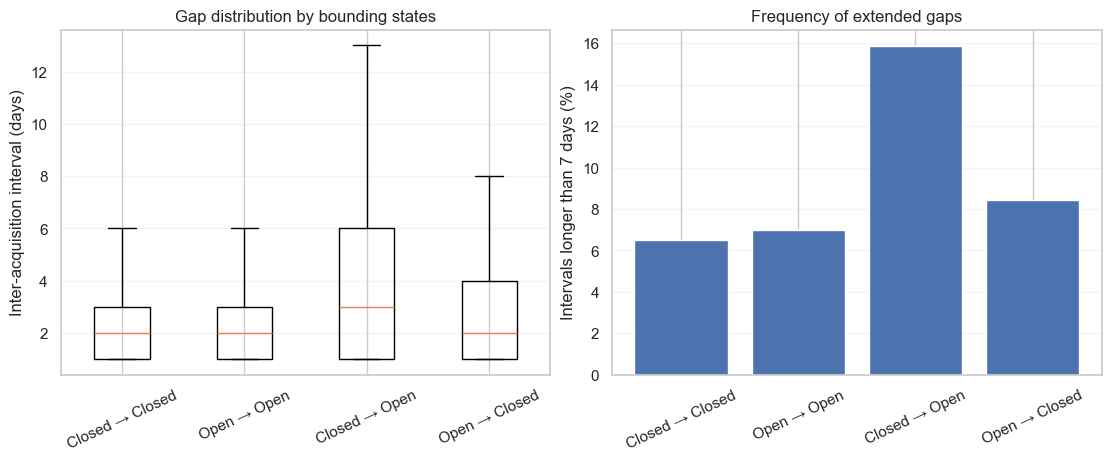

In [22]:
# Gap length as a function of the observed state before and after each gap

OPEN_THRESHOLD = 0.440

state_gaps = preds_all[["region", "acquired", "p_open"]].copy()
state_gaps["acquired"] = pd.to_datetime(state_gaps["acquired"], utc=True)
state_gaps = state_gaps[state_gaps["acquired"] > pd.Timestamp("2018-01-01", tz="UTC")].copy()

state_gaps["date"] = state_gaps["acquired"].dt.normalize()

# Collapse any remaining same-day observations by averaging their probabilities.
daily_states = (
    state_gaps.groupby(["region", "date"], as_index=False)
    .agg(p_open=("p_open", "mean"))
    .sort_values(["region", "date"])
)

daily_states["state"] = np.where(
    daily_states["p_open"] > OPEN_THRESHOLD,
    "Open",
    "Closed",
)

# Attach the preceding observed date and state.
daily_states["date_before"] = daily_states.groupby("region")["date"].shift()
daily_states["state_before"] = daily_states.groupby("region")["state"].shift()

intervals = daily_states.dropna(subset=["date_before", "state_before"]).copy()

intervals["interval_days"] = (intervals["date"] - intervals["date_before"]).dt.days

# Days with no observation between the bounding observations.
intervals["unobserved_days"] = (intervals["interval_days"] - 1).clip(lower=0)

intervals["state_after"] = intervals["state"]

intervals["boundary_type"] = np.where(
    intervals["state_before"] == intervals["state_after"],
    "Same state",
    "State changed",
)

intervals["transition"] = intervals["state_before"] + " → " + intervals["state_after"]

transition_order = [
    "Closed → Closed",
    "Open → Open",
    "Closed → Open",
    "Open → Closed",
]

# Same-state versus changed-state summary.
boundary_summary = intervals.groupby("boundary_type").agg(
    n_intervals=("interval_days", "size"),
    mean_interval_days=("interval_days", "mean"),
    median_interval_days=("interval_days", "median"),
    p90_interval_days=("interval_days", lambda x: x.quantile(0.90)),
    max_interval_days=("interval_days", "max"),
    total_unobserved_days=("unobserved_days", "sum"),
    pct_over_7_days=("interval_days", lambda x: 100 * (x > 7).mean()),
    pct_over_14_days=("interval_days", lambda x: 100 * (x > 14).mean()),
    pct_over_20_days=("interval_days", lambda x: 100 * (x > 20).mean()),
)

boundary_summary["pct_intervals"] = (
    100 * boundary_summary["n_intervals"] / boundary_summary["n_intervals"].sum()
)

boundary_summary["pct_unobserved_days"] = (
    100
    * boundary_summary["total_unobserved_days"]
    / boundary_summary["total_unobserved_days"].sum()
)

# Detailed before/after-state summary.
transition_summary = (
    intervals.groupby("transition")
    .agg(
        n_intervals=("interval_days", "size"),
        mean_interval_days=("interval_days", "mean"),
        median_interval_days=("interval_days", "median"),
        p90_interval_days=("interval_days", lambda x: x.quantile(0.90)),
        max_interval_days=("interval_days", "max"),
        total_unobserved_days=("unobserved_days", "sum"),
        pct_over_7_days=("interval_days", lambda x: 100 * (x > 7).mean()),
        pct_over_14_days=("interval_days", lambda x: 100 * (x > 14).mean()),
        pct_over_20_days=("interval_days", lambda x: 100 * (x > 20).mean()),
    )
    .reindex(transition_order)
)

display(boundary_summary.round(2))
display(transition_summary.round(2))

# Plot the distributions without allowing rare extreme gaps
# to compress the central portion of the boxplots.
plot_data = [
    intervals.loc[
        intervals["transition"] == transition,
        "interval_days",
    ].dropna()
    for transition in transition_order
]

fig, axes = plt.subplots(
    ncols=2,
    figsize=(11, 4.5),
    constrained_layout=True,
)

axes[0].boxplot(
    plot_data,
    labels=transition_order,
    showfliers=False,
)
axes[0].set_ylabel("Inter-acquisition interval (days)")
axes[0].set_title("Gap distribution by bounding states")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.25)

long_gap_pct = [100 * (values > 7).mean() for values in plot_data]

axes[1].bar(transition_order, long_gap_pct)
axes[1].set_ylabel("Intervals longer than 7 days (%)")
axes[1].set_title("Frequency of extended gaps")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25)

plt.show()

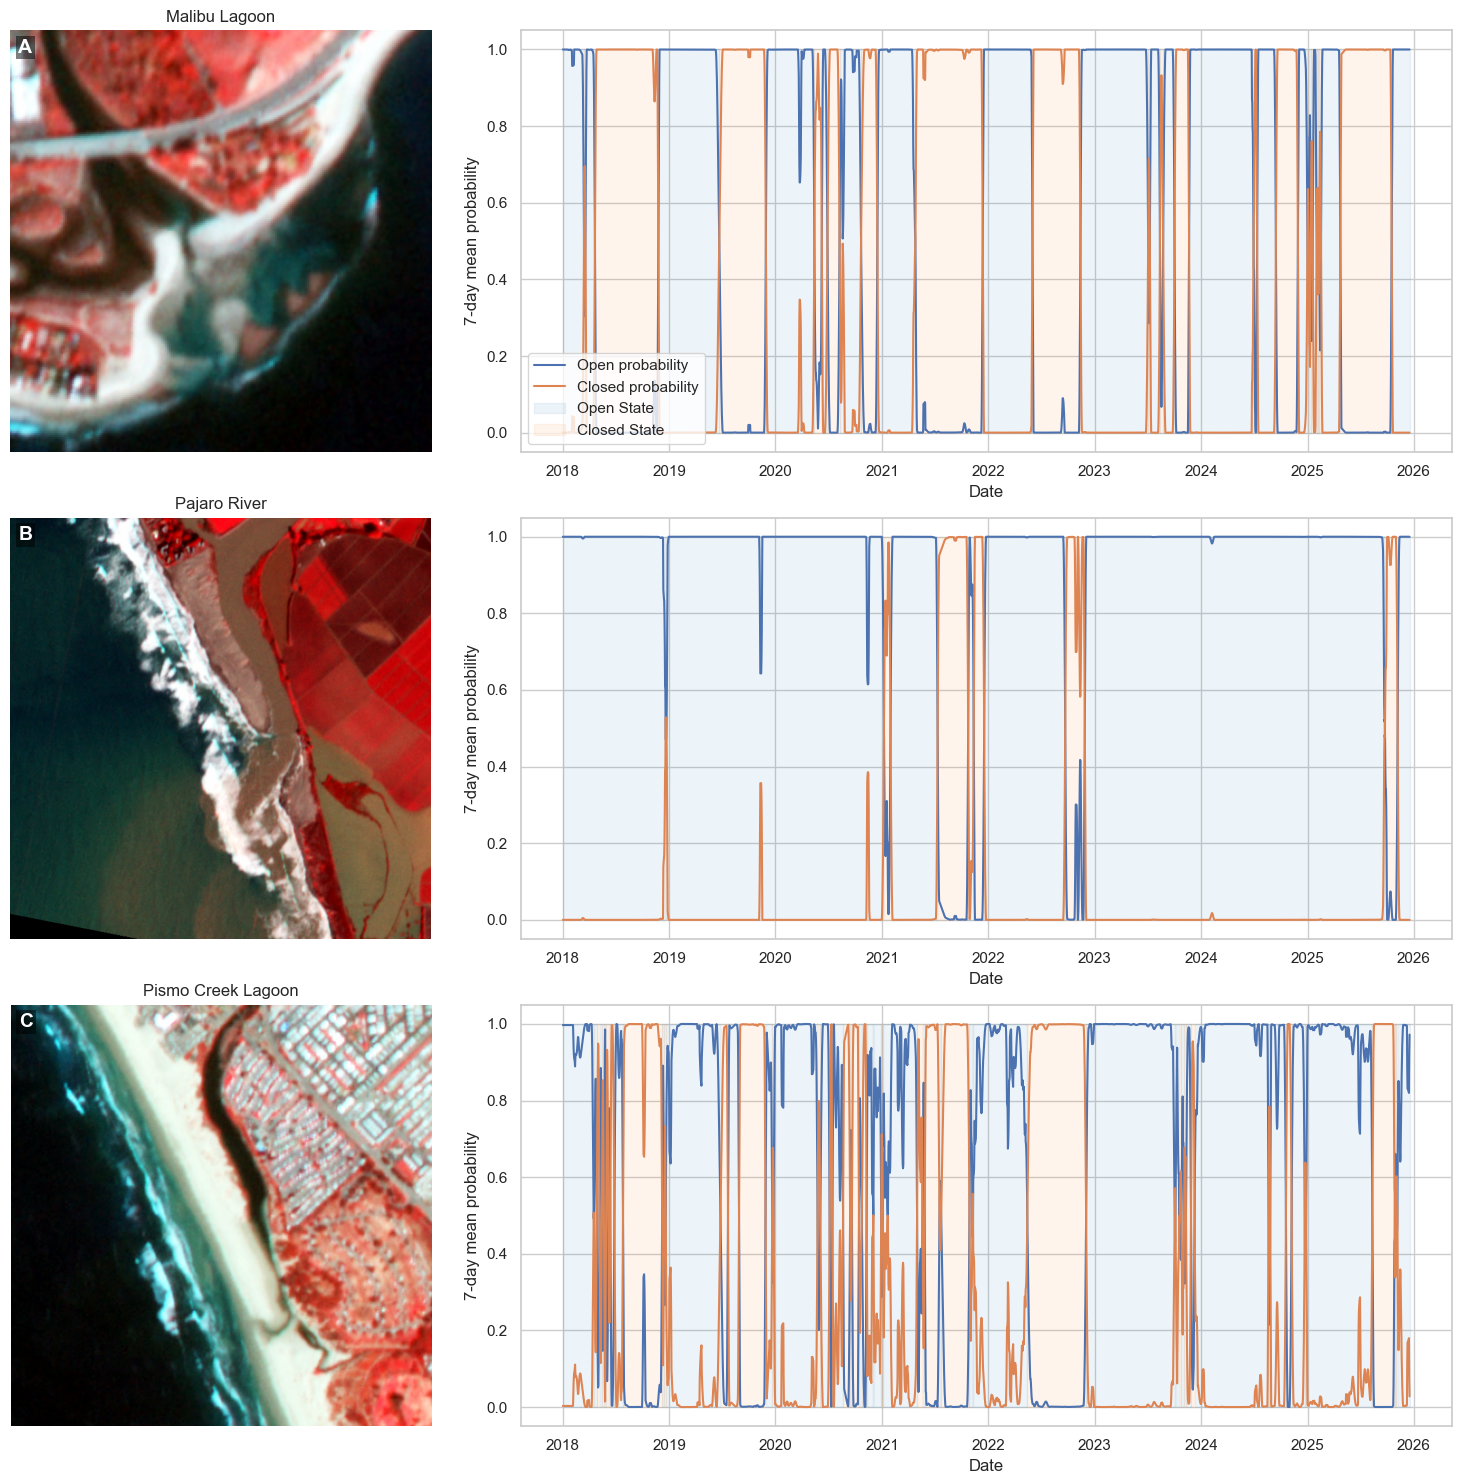

In [23]:
from scripts.display.generate_submission_figures import figure_5

figure_5(gdf, preds_all, full, SAVE_DIR)

"""Legacy inline implementation retained for provenance.
def plot_timeseries(region, ax, legend=False):
    df = full.loc[region].sort_index()

    pcols = ["p_open", "p_closed"]
    df_roll = df[pcols].rolling("7D", min_periods=1).mean()

    ax.plot(df_roll.index, df_roll["p_open"], label="Open probability", lw=1.5)
    ax.plot(df_roll.index, df_roll["p_closed"], label="Closed probability", lw=1.5)

    dominant = df_roll.idxmax(axis=1)

    colors = {"p_open": "tab:blue", "p_closed": "tab:orange"}

    for col, color in colors.items():
        mask = dominant == col
        name = col.split("_")[1].capitalize()
        ax.fill_between(
            df_roll.index, 0, 1, where=mask, color=color, alpha=0.08, label=f"{name} State"
        )

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("7-day mean probability")
    ax.set_xlabel("Date")
    if legend:
        ax.legend(loc="lower left")
        # ax.set_title("7-day mean probability")


def plot_image(pth, ax):
    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax.imshow(img)
    ax.axis("off")


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15), gridspec_kw={"width_ratios": [1, 2]})

region = 2145
name = gdf.loc[region]["Estuary_Name"]
plot_timeseries(region, axes[0, 1], legend=True)
pth = preds_all[(preds_all.region == region) & (preds_all.y_pred == 1)].iloc[100].source_tif
plot_image(pth, axes[0, 0])
axes[0, 0].set_title(f"{name}")

region = 51
name = gdf.loc[region]["Estuary_Name"]
plot_timeseries(region, axes[1, 1])
pth = preds_all[(preds_all.region == region) & (preds_all.y_pred == 1)].iloc[0].source_tif
plot_image(pth, axes[1, 0])
axes[1, 0].set_title(f"{name}")

region = 35
name = gdf.loc[region]["Estuary_Name"]
plot_timeseries(region, axes[2, 1])
pth = (
    preds_all[(preds_all.region == region) & (preds_all.y_pred == 1) & (preds_all.p_open < 0.9)]
    .iloc[1]
    .source_tif
)
plot_image(pth, axes[2, 0])
axes[2, 0].set_title(f"{name}")

abc = ["A", "B", "C"]

# after plotting all three rows, before fig.tight_layout()
for i, label in enumerate(abc):
    axes[i, 0].text(
        0.02,
        0.98,
        label,
        transform=axes[i, 0].transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
        color="white",
        bbox=dict(facecolor="black", edgecolor="none", alpha=0.5, pad=2),
    )

fig.tight_layout()

# fig.savefig(
#     SAVE_DIR / "fig05_example_connectivity_time_series.pdf",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     dpi=300,
# )

fig.savefig(
    SAVE_DIR / "fig05_example_connectivity_time_series.tif",
    bbox_inches="tight",
    pad_inches=0.25,
    dpi=300,
)

plt.show()
"""

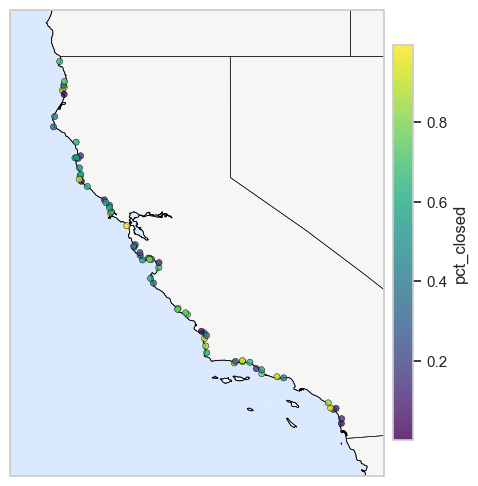

In [24]:
from scripts.display.generate_submission_figures import figure_6

figure_6(gdf_points, full, SAVE_DIR)

"""Legacy closed-probability implementation retained for provenance.
mean_frac = full["p_closed"].groupby(level="region").mean().rename("pct_closed")
g = gdf_points.join(mean_frac, how="left")

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(5, 6),
    # constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_estuaries_ca(
    g,
    ax=ax,
    column="pct_closed",
    cmap="viridis",
    # title="% Time Closed",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
    # save_path=FIG_DIR / "state_map_p_closed.png",
)

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "fig06_state_map_p_closed.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=300,
)

plt.show()
"""

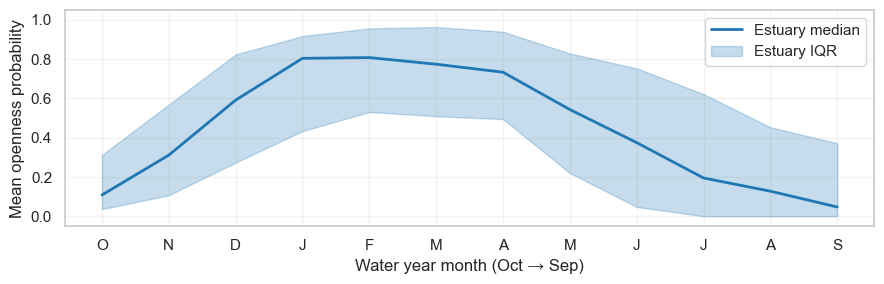

In [25]:
from scripts.display.generate_submission_figures import figure_7

figure_7(full, SAVE_DIR)

"""Legacy inline implementation retained for provenance.
tmp = full.reset_index().copy()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp["wy_month"] = (tmp["date"].dt.month - 10) % 12

region_month = tmp.groupby(["region", "wy_month"])["p_open"].mean().reset_index()

q = (
    region_month.groupby("wy_month")["p_open"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
)

months = np.arange(12)
month_labels = ["O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A", "S"]

fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(months, q["median"], lw=2, color="tab:blue", label="Estuary median")
ax.fill_between(months, q["q25"], q["q75"], color="tab:blue", alpha=0.25, label="Estuary IQR")

ax.set_ylim(-0.05, 1.05)
ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_xlabel("Water year month (Oct → Sep)")
ax.set_ylabel("Mean openness probability")
# ax.set_title("Statewide seasonal openness across regions")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "fig07_statewide_seasonal_openness.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
)

plt.show()
"""

In [26]:
# # curl https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/4/pcp/12/9/2017-2025.csv?base_prd=true

# raw = """Date,Value,Anomaly
# 201809,15.82,-6.63
# 201909,28.37,5.92
# 202009,15.64,-6.81
# 202109,11.13,-11.32
# 202209,16.42,-6.03
# 202309,30.89,8.44
# 202409,22.97,0.52
# 202509,20.44,-2.01
# """

# precip = pd.read_csv(StringIO(raw))

# # Parse YYYYMM → datetime
# precip["date"] = pd.to_datetime(precip["Date"].astype(str), format="%Y%m")

# # Water year is just the year (since these are September-ending totals)
# precip["water_year"] = precip["date"].dt.year

# # Clean numeric columns
# precip["precip_in"] = pd.to_numeric(precip["Value"], errors="coerce")
# precip["anomaly_in"] = pd.to_numeric(precip["Anomaly"], errors="coerce")

# # Final tidy table
# precip = precip[["water_year", "precip_in", "anomaly_in"]].sort_values("water_year")

# precip

In [27]:
# color = "tab:blue"

# # -----------------------------------
# # Prepare data
# # -----------------------------------
# tmp = full.reset_index().copy()
# tmp["date"] = pd.to_datetime(tmp["date"])
# tmp["water_year"] = tmp["date"].dt.year + (tmp["date"].dt.month >= 10).astype(int)


# def season_from_month(m):
#     if m in [10, 11, 12]:
#         return "Fall"
#     if m in [1, 2, 3]:
#         return "Winter"
#     if m in [4, 5, 6]:
#         return "Spring"
#     return "Summer"  # July, August, September


# tmp["season"] = tmp["date"].dt.month.map(season_from_month)

# # Keep only complete water years
# tmp = tmp[(tmp["water_year"] >= 2019) & (tmp["water_year"] <= 2025)].copy()

# # -----------------------------------
# # Estuary-year-season means
# # -----------------------------------
# eys = (
#     tmp.groupby(["region", "water_year", "season"])["p_open"]
#     .mean()
#     .reset_index()
#     .merge(precip[["water_year", "precip_in"]], on="water_year", how="inner")
# )


# # -----------------------------------
# # Summarize across estuaries within each WY × season
# # -----------------------------------
# def q25(x):
#     return np.nanpercentile(x, 25)


# def q75(x):
#     return np.nanpercentile(x, 75)

# def q50(x):
#     return np.nanpercentile(x, 50)


# summ = (
#     eys.groupby(["season", "water_year"])
#     .agg(
#         precip_in=("precip_in", "first"),
#         median=("p_open", q50),
#         q25=("p_open", q25),
#         q75=("p_open", q75),
#     )
#     .reset_index()
# )

# # -----------------------------------
# # Plot
# # -----------------------------------
# season_order = ["Fall", "Winter", "Spring", "Summer"]

# fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

# for ax, season in zip(axes.flatten(), season_order):
#     d = summ[summ["season"] == season].sort_values("water_year").copy()

#     x = d["precip_in"].to_numpy()
#     y = d["median"].to_numpy()
#     ylo = d["q25"].to_numpy()
#     yhi = d["q75"].to_numpy()
#     yerr = np.vstack([y - ylo, yhi - y])

#     # Scatter with IQR bars
#     ax.errorbar(
#         x,
#         y,
#         yerr=yerr,
#         fmt="o",
#         ms=8,
#         color=color,
#         ecolor=color,
#         elinewidth=1.5,
#         capsize=4,
#         alpha=0.9,
#     )

#     # Linear fit
#     if len(x) > 1 and np.isfinite(x).all() and np.isfinite(y).all():
#         m, b = np.polyfit(x, y, 1)
#         xs = np.linspace(x.min(), x.max(), 100)
#         ax.plot(xs, m * xs + b, color="black", linewidth=2, alpha=0.8, linestyle="--")
#     else:
#         m = np.nan

#     # Spearman correlation
#     if len(d) > 1:
#         rho, p = spearmanr(d["precip_in"], d["median"])
#     else:
#         rho, p = np.nan, np.nan

#     ax.text(
#         0.03,
#         0.95,
#         f"slope = {m:.3f}\nrho = {rho:.2f}\np = {p:.2f}",
#         transform=ax.transAxes,
#         fontsize=9,
#         va="top",
#     )

#     # Annotate water year
#     for _, r in d.iterrows():
#         ax.text(
#             r["precip_in"] + 0.15,
#             r["median"],
#             str(int(r["water_year"])),
#             fontsize=8,
#             alpha=0.8,
#         )

#     ax.set_title(season)
#     ax.set_ylim(-0.1, 1.1)
#     ax.grid(True, alpha=0.3)

# axes[0, 0].set_ylabel("Median predicted openness")
# axes[1, 0].set_ylabel("Median predicted openness")
# axes[1, 0].set_xlabel("CA Water-Year Precipitation (inches)")
# axes[1, 1].set_xlabel("CA Water-Year Precipitation (inches)")

# # fig.suptitle(
# #     "Seasonal openness vs water-year precipitation\n"
# #     "(dot = median across estuaries; bars = IQR across estuaries; dashed line = linear fit)",
# #     y=0.98,
# # )

# fig.tight_layout()

# fig.savefig(
#     SAVE_DIR / "fig08_precipitation_vs_seasonal_openness.pdf",
#     bbox_inches="tight",
#     pad_inches=0.1,
# )

# plt.show()

### Exploratory test: seasonal openness vs. 3-, 6-, 9-, and 12-month precipitation

This is separate from Figure 8. Fall is October-December, followed by Winter, Spring, and Summer.

In [28]:
import subprocess

window_ncei_url = (
    "https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/"
    "statewide/time-series/4/pcp/{window}/{end_month}/2017-2025.csv"
)
window_season_order = ["Fall", "Winter", "Spring", "Summer"]
window_season_end_month = {"Fall": 12, "Winter": 3, "Spring": 6, "Summer": 9}
window_season_months = {
    "Fall": {10, 11, 12},
    "Winter": {1, 2, 3},
    "Spring": {4, 5, 6},
    "Summer": {7, 8, 9},
}

# Fetch the 16 precipitation series: four season-end months x four windows.
window_precip_parts = []
for window_months in (3, 6, 9, 12):
    for window_season, window_end_month in window_season_end_month.items():
        window_url = window_ncei_url.format(window=window_months, end_month=window_end_month)
        window_response = subprocess.run(
            [
                "curl",
                "-fsSL",
                "--connect-timeout",
                "10",
                "--max-time",
                "30",
                f"{window_url}?base_prd=true",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        window_part = pd.read_csv(StringIO(window_response.stdout), comment="#")
        window_part["date"] = pd.to_datetime(window_part["Date"].astype(str), format="%Y%m")
        window_part["precip_in"] = pd.to_numeric(window_part["Value"], errors="coerce")
        window_part["water_year"] = window_part["date"].dt.year + int(window_end_month == 12)
        window_part["season"] = window_season
        window_part["window_months"] = window_months
        window_part["source_url"] = window_url
        window_precip_parts.append(window_part)

window_precip = (
    pd.concat(window_precip_parts, ignore_index=True)[
        ["water_year", "season", "window_months", "precip_in", "source_url"]
    ]
    .sort_values(["window_months", "season", "water_year"])
    .reset_index(drop=True)
)

window_tmp = full.reset_index().copy()
window_tmp["date"] = pd.to_datetime(window_tmp["date"])
window_tmp["water_year"] = window_tmp["date"].dt.year + (window_tmp["date"].dt.month >= 10).astype(
    int
)
window_tmp["season"] = window_tmp["date"].dt.month.map(
    {month: season for season, months in window_season_months.items() for month in months}
)
window_tmp = window_tmp[window_tmp["water_year"].between(2019, 2025)].copy()

window_eys = (
    window_tmp.groupby(["region", "water_year", "season"], as_index=False)["p_open"]
    .mean()
    .merge(window_precip, on=["water_year", "season"], how="inner")
)
window_summ = window_eys.groupby(["window_months", "season", "water_year"], as_index=False).agg(
    precip_in=("precip_in", "first"),
    median=("p_open", "median"),
    q25=("p_open", lambda x: np.nanpercentile(x, 25)),
    q75=("p_open", lambda x: np.nanpercentile(x, 75)),
)

window_fig, window_axes = plt.subplots(4, 4, figsize=(14, 13), sharey=True)
window_stats = []
for window_row, window_months in enumerate((3, 6, 9, 12)):
    for window_col, window_season in enumerate(window_season_order):
        window_ax = window_axes[window_row, window_col]
        window_d = window_summ[
            (window_summ["window_months"] == window_months)
            & (window_summ["season"] == window_season)
        ].sort_values("water_year")

        window_x = window_d["precip_in"].to_numpy()
        window_y = window_d["median"].to_numpy()
        window_yerr = np.vstack(
            [
                window_y - window_d["q25"].to_numpy(),
                window_d["q75"].to_numpy() - window_y,
            ]
        )
        window_ax.errorbar(
            window_x,
            window_y,
            yerr=window_yerr,
            fmt="o",
            ms=7,
            color="tab:blue",
            ecolor="tab:blue",
            elinewidth=1.3,
            capsize=3,
            alpha=0.9,
        )

        window_valid = np.isfinite(window_x) & np.isfinite(window_y)
        if window_valid.sum() > 1:
            window_m, window_b = np.polyfit(window_x[window_valid], window_y[window_valid], 1)
            window_xs = np.linspace(window_x[window_valid].min(), window_x[window_valid].max(), 100)
            window_ax.plot(
                window_xs,
                window_m * window_xs + window_b,
                color="black",
                linewidth=1.7,
                linestyle="--",
            )
            window_rho, window_p = spearmanr(window_x[window_valid], window_y[window_valid])
        else:
            window_m, window_rho, window_p = np.nan, np.nan, np.nan

        window_stats.append(
            {
                "window_months": window_months,
                "season": window_season,
                "slope": window_m,
                "rho": window_rho,
                "p": window_p,
            }
        )
        window_ax.text(
            0.03,
            0.97,
            f"slope = {window_m:.3f}\nρ = {window_rho:.2f}\np = {window_p:.2f}",
            transform=window_ax.transAxes,
            fontsize=8.5,
            va="top",
        )
        for _, window_record in window_d.iterrows():
            window_ax.annotate(
                str(int(window_record["water_year"])),
                (window_record["precip_in"], window_record["median"]),
                xytext=(4, 2),
                textcoords="offset points",
                fontsize=7,
                alpha=0.8,
            )
        if window_row == 0:
            window_ax.set_title(window_season)
        if window_col == 0:
            window_ax.set_ylabel("Median predicted openness")
        window_ax.set_xlabel(f"{window_months}-month precipitation (inches)")
        window_ax.set_ylim(-0.1, 1.1)
        # window_ax.set_xlim(0, 35)
        window_ax.grid(True, alpha=0.3)

window_fig.tight_layout()
# window_fig.savefig(
#     SAVE_DIR / "test_precipitation_windows_vs_seasonal_openness.pdf",
#     bbox_inches="tight",
#     pad_inches=0.1,
# )
window_stats = pd.DataFrame(window_stats)
display(window_stats)
plt.show()

CalledProcessError: Command '['curl', '-fsSL', '--connect-timeout', '10', '--max-time', '30', 'https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/4/pcp/3/12/2017-2025.csv?base_prd=true']' returned non-zero exit status 22.

### Candidate Figure 8: seasonal openness vs. cumulative water-year precipitation

This leaves the original water-year Figure 8 cell above intact.

In [ ]:
wytd_color = "tab:blue"
wytd_season_order = ["Fall", "Winter", "Spring", "Summer"]
wytd_window_by_season = {"Fall": 3, "Winter": 6, "Spring": 9, "Summer": 12}
wytd_season_map = {
    10: "Fall",
    11: "Fall",
    12: "Fall",
    1: "Winter",
    2: "Winter",
    3: "Winter",
    4: "Spring",
    5: "Spring",
    6: "Spring",
    7: "Summer",
    8: "Summer",
    9: "Summer",
}

# Cumulative precipitation since the October start of each water year:
# Fall = Oct-Dec (3 months), Winter = Oct-Mar (6),
# Spring = Oct-Jun (9), and Summer = Oct-Sep (12).
wytd_precip = window_precip.loc[
    window_precip["window_months"] == window_precip["season"].map(wytd_window_by_season),
    ["water_year", "season", "window_months", "precip_in"],
].copy()

wytd_tmp = full.reset_index().copy()
wytd_tmp["date"] = pd.to_datetime(wytd_tmp["date"])
wytd_tmp["water_year"] = wytd_tmp["date"].dt.year + (wytd_tmp["date"].dt.month >= 10).astype(int)
wytd_tmp["season"] = wytd_tmp["date"].dt.month.map(wytd_season_map)
wytd_tmp = wytd_tmp[wytd_tmp["water_year"].between(2019, 2025)].copy()

wytd_eys = (
    wytd_tmp.groupby(["region", "water_year", "season"], as_index=False)["p_open"]
    .mean()
    .merge(
        wytd_precip,
        on=["water_year", "season"],
        how="inner",
        validate="many_to_one",
    )
)

wytd_summ = wytd_eys.groupby(["season", "water_year"], as_index=False).agg(
    precip_in=("precip_in", "first"),
    median=("p_open", "median"),
    q25=("p_open", lambda x: np.nanpercentile(x, 25)),
    q75=("p_open", lambda x: np.nanpercentile(x, 75)),
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
wytd_stats = []

for ax, season in zip(axes.flatten(), wytd_season_order):
    d = wytd_summ[wytd_summ["season"] == season].sort_values("water_year")
    x = d["precip_in"].to_numpy()
    y = d["median"].to_numpy()
    yerr = np.vstack([y - d["q25"].to_numpy(), d["q75"].to_numpy() - y])

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        ms=8,
        color=wytd_color,
        ecolor=wytd_color,
        elinewidth=1.5,
        capsize=4,
        alpha=0.9,
    )

    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() > 1:
        m, b = np.polyfit(x[valid], y[valid], 1)
        xs = np.linspace(x[valid].min(), x[valid].max(), 100)
        ax.plot(
            xs,
            m * xs + b,
            color="black",
            linewidth=2,
            alpha=0.8,
            linestyle="--",
        )
        rho, p = spearmanr(x[valid], y[valid])
    else:
        m, rho, p = np.nan, np.nan, np.nan

    wytd_stats.append(
        {
            "season": season,
            "window_months": wytd_window_by_season[season],
            "slope": m,
            "rho": rho,
            "p": p,
        }
    )
    ax.text(
        0.03,
        0.95,
        f"slope = {m:.3f}\nρ = {rho:.2f}\np = {p:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
    )

    for _, record in d.iterrows():
        ax.annotate(
            str(int(record["water_year"])),
            (record["precip_in"], record["median"]),
            xytext=(4, 2),
            textcoords="offset points",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(f"{season} ({wytd_window_by_season[season]} months)")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Median predicted openness")
axes[1, 0].set_ylabel("Median predicted openness")
fig.supxlabel("Cumulative precipitation since water-year start (inches)")
fig.tight_layout()

fig.savefig(
    SAVE_DIR / "fig08_precipitation_vs_seasonal_openness.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
)

wytd_stats = pd.DataFrame(wytd_stats)
display(wytd_stats)
plt.show()

In [ ]:
# Previous-water-year precipitation versus residual openness
#
# Residual openness is the vertical distance above or below the fitted
# current-water-year precipitation line in Figure 8.

lag_color = "tab:purple"

# The 12-month precipitation series ending in September represents the
# complete water-year total. Shift its water-year label forward by one
# so that, for example, WY2023 precipitation predicts WY2024 openness.
prior_wy_precip = (
    window_precip.loc[
        (window_precip["season"] == "Summer") & (window_precip["window_months"] == 12),
        ["water_year", "precip_in"],
    ]
    .rename(columns={"precip_in": "prior_wy_precip_in"})
    .copy()
)

prior_wy_precip["water_year"] += 1

lagged_summ = wytd_summ.merge(
    prior_wy_precip,
    on="water_year",
    how="inner",
    validate="many_to_one",
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
lagged_stats = []

for ax, season in zip(axes.flatten(), wytd_season_order):
    d = lagged_summ.loc[lagged_summ["season"] == season].sort_values("water_year").copy()

    current_precip = d["precip_in"].to_numpy()
    openness = d["median"].to_numpy()
    prior_precip = d["prior_wy_precip_in"].to_numpy()

    valid = np.isfinite(current_precip) & np.isfinite(openness) & np.isfinite(prior_precip)

    # Reproduce the Figure 8 current-precipitation regression.
    current_slope, current_intercept = np.polyfit(
        current_precip[valid],
        openness[valid],
        1,
    )

    # Positive residual = point lies above the Figure 8 regression line.
    residual = openness - (current_slope * current_precip + current_intercept)
    d["openness_residual"] = residual

    # Retain the original across-estuary IQR as error bars.
    yerr = np.vstack(
        [
            d["median"].to_numpy() - d["q25"].to_numpy(),
            d["q75"].to_numpy() - d["median"].to_numpy(),
        ]
    )

    ax.errorbar(
        prior_precip,
        residual,
        yerr=yerr,
        fmt="o",
        ms=8,
        color=lag_color,
        ecolor=lag_color,
        elinewidth=1.5,
        capsize=4,
        alpha=0.9,
    )

    # Fit the exploratory lagged relationship.
    lag_slope, lag_intercept = np.polyfit(
        prior_precip[valid],
        residual[valid],
        1,
    )
    xs = np.linspace(
        prior_precip[valid].min(),
        prior_precip[valid].max(),
        100,
    )

    ax.plot(
        xs,
        lag_slope * xs + lag_intercept,
        color="black",
        linewidth=2,
        linestyle="--",
        alpha=0.8,
    )
    ax.axhline(0, color="0.5", linewidth=1, linestyle=":")

    rho, p = spearmanr(
        prior_precip[valid],
        residual[valid],
    )

    lagged_stats.append(
        {
            "season": season,
            "n": int(valid.sum()),
            "lag_residual_slope": lag_slope,
            "rho": rho,
            "p": p,
        }
    )

    ax.text(
        0.03,
        0.95,
        f"slope = {lag_slope:.3f}\nρ = {rho:.2f}\np = {p:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
    )

    for _, record in d.iterrows():
        ax.annotate(
            str(int(record["water_year"])),
            (
                record["prior_wy_precip_in"],
                record["openness_residual"],
            ),
            xytext=(4, 2),
            textcoords="offset points",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(season)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Openness residual\n(after current-year precipitation)")
axes[1, 0].set_ylabel("Openness residual\n(after current-year precipitation)")
fig.supxlabel("Previous water-year precipitation (inches)")
fig.tight_layout()

# Keep this exploratory figure separate from the official submission figure.
# fig.savefig(
#     SAVE_DIR / "test_prior_water_year_precipitation_residuals.pdf",
#     bbox_inches="tight",
#     pad_inches=0.1,
# )

lagged_stats = pd.DataFrame(lagged_stats)
display(lagged_stats)
plt.show()

In [ ]:
from scripts.display.generate_supplementary_figures import figure_s1

figure_s1(SAVE_DIR)

"""Legacy inline implementation retained for provenance.
pths = [
    # Clouds
    "/Users/kyledorman/data/estuary/dataset/images/dove/results/2017/7/2147/files/20170723_181219_1007_3B_AnalyticMS_SR_clip.tif",
    # Haze
    "/Users/kyledorman/data/estuary/dataset/images/dove/results/2018/6/43/files/20180609_181605_1021_3B_AnalyticMS_SR_clip.tif",
    # Noise
    "/Users/kyledorman/data/estuary/dataset/images/dove/results/2022/3/83/files/20220302_181207_0e20_3B_AnalyticMS_SR_clip.tif",
    # Shift
    "/Users/kyledorman/data/estuary/dataset/images/dove/results/2018/12/81/files/20181203_183436_1001_3B_AnalyticMS_SR_clip.tif",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for pth, ax in zip(pths, axes.flatten()):
    with rasterio.open(pth) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)
    ax.imshow(img)
    ax.axis("off")

labels = ["A", "B", "C", "D"]

for ax, label in zip(axes.flatten(), labels):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
        color="white",
        bbox=dict(facecolor="black", edgecolor="none", alpha=0.5, pad=2),
    )

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "figS01_low_quality_examples.tif",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=300,
)

plt.show()
"""

In [ ]:
from scripts.display.generate_supplementary_figures import figure_s2

figure_s2(d_ss_pairs, dd_pairs, SAVE_DIR)

"""Legacy separate S2/S3 implementation retained for provenance.
# -------------------------------------------------------
# 3-CLASS CONFUSION MATRIX
# -------------------------------------------------------

labels = ["closed", "perched open", "open"]
disp_labels = ["Closed", "Partial", "Open"]

y_true = np.array([labels.index(l) for l in d_ss_pairs.label_ss])
y_pred = np.array([labels.index(l) for l in d_ss_pairs.label_dd])

print("Image only & SkySat Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Image only & SkySat Perch F1", round(f1_score(y_true == 1, y_pred == 1), 3))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=disp_labels,
    yticklabels=disp_labels,
    cbar=False,
    ax=ax,
)

ax.set_xlabel("PlanetScope label")
ax.set_ylabel("SkySat label")

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "figS02_dove_skysat_confusion_matrix.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

labels = ["closed", "perched open", "open"]
disp_labels = ["Closed", "Partial", "Open"]

y_true = np.array([labels.index(l) for l in dd_pairs.label_water])
y_pred = np.array([labels.index(l) for l in dd_pairs.label_img])

print("Image only & Water Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Image only & Water Perch F1", round(f1_score(y_true == 1, y_pred == 1), 3))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=disp_labels,
    yticklabels=disp_labels,
    cbar=False,
    ax=ax,
)

ax.set_xlabel("Image-only label")
ax.set_ylabel("Image + water-level label")

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "figS03_dove_water_confusion_matrix.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()
"""

In [ ]:
def inspect_row(iii, suffix_t, suffix_p, title_left, title_right, save_path=None):
    _, row = next(iii)
    if "acquired" in row:
        date = str(row.acquire.date())
    else:
        date = str(row[f"acquired{suffix_p}"].date())

    with rasterio.open(row[f"source_tif{suffix_t}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        t = false_color(data, nodata)

    with rasterio.open(row[f"source_tif{suffix_p}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        p = false_color(data, nodata)

    label_t = row[f"label{suffix_t}"]
    label_p = row[f"label{suffix_p}"]

    if label_p == "perched open":
        label_p = "partial"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # axes[0].set_title(f"{title_left} Label: {label_t.capitalize()}")
    # axes[1].set_title(f"{title_right} Label: {label_p.capitalize()}")

    axes[0].imshow(t)
    axes[0].axis("off")
    axes[1].imshow(p)
    axes[1].axis("off")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            bbox_inches="tight",
            pad_inches=0.02,
            dpi=300,
        )

    plt.show()

In [ ]:
inspect = d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "perched open")]
inspect_iter = inspect.iterrows()
next(inspect_iter)

In [ ]:
from scripts.display.generate_supplementary_figures import figure_s3

figure_s3(d_ss_pairs, SAVE_DIR)

In [ ]:
def calc_f1(rdf):
    return f1_score(rdf.y_true, rdf.y_pred, labels=[0, 1], zero_division=1)


"/Volumes/x10pro/results/"
comp_params = []

main_preds = pd.read_csv("/Volumes/x10pro/results/estuary/train/20260305-095554/train_preds.csv")
main_preds = main_preds[(main_preds.year == 2025) & (main_preds.y_true >= 0)].copy()
main_preds["Model"] = "ConvNeXt-Tiny"
main_preds["Pretraining"] = "dinov3_lvd1689m"
main_preds["Bands"] = "NIR-R-G"
comp_params.append(main_preds)

pp = pd.read_csv("/Volumes/x10pro/results/estuary/train/20260309-131506/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXt-Tiny"
pp["Pretraining"] = "ImageNet-22K"
pp["Bands"] = "NIR-R-G"
comp_params.append(pp)

pp = pd.read_csv("/Volumes/x10pro/results/estuary/train/20260309-154804/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXtV2-Tiny"
pp["Pretraining"] = "FCMAE"
pp["Bands"] = "NIR-R-G"
comp_params.append(pp)

pp = pd.read_csv("/Volumes/x10pro/results/estuary/train/20260309-165440/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXtV2-Tiny"
pp["Pretraining"] = "FCMAE and ImageNet-22K"
pp["Bands"] = "NIR-R-G"
comp_params.append(pp)

pp = pd.read_csv("/Volumes/x10pro/results/estuary/train/20260311-095816/train_preds.csv")
pp = pp[(pp.year == 2025) & (pp.y_true >= 0)].copy()
pp["Model"] = "ConvNeXt-Tiny"
pp["Pretraining"] = "dinov3_lvd1689m"
pp["Bands"] = "RGB"
comp_params.append(pp)

run_params = pd.concat(comp_params)

table = (
    run_params.groupby(["Model", "Pretraining", "Bands"])
    .apply(calc_f1, include_groups=False)
    .round(2)
    .rename("F1")
    .sort_values(ascending=False)
    .to_frame()
    .reset_index()
)

print("\nResults Table\n")
print(table.to_markdown(index=False))

# Source-of-truth table for reproducibility
table.to_csv(SAVE_DIR / "tableS01_pretraining_band_comparison.csv", index=False)

In [ ]:
def dove_from_date(region, date):
    base = Path("/Volumes/x10pro/estuary/sat_data/")
    pth = list(
        base.glob(
            f"*ove/results/{date.year}/{date.month}/{region}/files/{date.year}{date.month:02}{date.day:02}*_SR*clip.tif"
        )
    )[0]
    print("dove", pth.stem)
    with rasterio.open(pth) as src:
        data = src.read(out_dtype=np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    nir = data[3]
    g = data[1]
    num = g - nir
    denom = g + nir
    wi = num / denom.clip(1, denom.max())

    return img, wi


def s2_false_color(bands):
    nodata = (bands == 0).all(axis=0)
    img = normalized_image_3_channel(bands, nodata, (7, 3, 2)).transpose((1, 2, 0))
    k = 1.5
    img = np.tanh(k * img) / np.tanh(k)
    img = np.array(img * 255, dtype=np.uint8)
    return img


def skysat_from_date(region, date):
    base = Path(f"/Volumes/x10pro/estuary/sat_data/skysat/results/{date.year}/{region}/files/")
    pth = list(base.glob(f"{date.year}{date.month:02}{date.day:02}*_pansharpened_clip.tif"))[0]
    print("skysat", pth.stem)
    with rasterio.open(pth) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    nir = data[3]
    g = data[1]
    num = g - nir
    denom = g + nir
    wi = num / denom.clip(1, denom.max())

    return img, wi


def s2_mdwi(s2_dir):
    band_names = ["B03", "B11"]
    bands = []
    for name in band_names:
        file = list(s2_dir.glob(f"*_{name}_*"))[0]
        with rasterio.open(file) as src:
            bands.append(src.read(1, out_dtype=np.float32))

    denom = bands[0] + bands[1]
    num = bands[0] - bands[1]

    return num / denom.clip(1, denom.max())


def s2_awei_img(s2_dir):
    bands = []
    for name in S2_BAND_NAMES:
        file = list(s2_dir.glob(f"*_{name}_*"))[0]
        with rasterio.open(file) as src:
            bands.append(src.read(1, out_dtype=np.float32))

    green = bands[2]
    NIR = bands[7]
    SWIR = bands[10]
    MIR = bands[11]
    AWEI = (4 * (green - MIR)) - (0.25 * NIR - 2.75 * SWIR)
    return AWEI
    # return contrast_stretch(np.log10(1 + AWEI - AWEI.min()))


S2_BAND_NAMES = [
    "B01",
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B09",
    "B11",
    "B12",
]


def s2_img(s2_dir):
    bands = []
    for name in S2_BAND_NAMES:
        file = list(s2_dir.glob(f"*_{name}_*"))[0]
        with rasterio.open(file) as src:
            bands.append(src.read(1, out_dtype=np.float32))

    return s2_false_color(np.array(bands))


def s2_img_from_date(date):
    pth = Path(
        f"/Users/kyledorman/data/estuary/sat_compare/sentinel/s2-{date.month:02}-{date.day:02}-{date.year}/"
    )
    print("s2", pth.stem)
    img = s2_img(pth)
    wi = s2_mdwi(pth)
    return img, wi


def plot_stats(region, date, save_dir: Path | None = None):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5.2))

    s2i, s2w = s2_img_from_date(date)
    dovei, dovew = dove_from_date(region, date)
    ssi, ssw = skysat_from_date(region, date)

    panels = [
        (axes[0], ssi, "A"),
        (axes[1], dovei, "B"),
        (axes[2], s2i, "C"),
    ]

    for ax, img, label in panels:
        ax.imshow(img)
        ax.axis("off")
        ax.text(
            0.02,
            0.98,
            label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
            fontweight="bold",
            color="white",
            bbox=dict(facecolor="black", edgecolor="none", alpha=0.5, pad=2),
        )

    fig.tight_layout()

    if save_dir is not None:
        save_dir.mkdir(exist_ok=True, parents=True)
        save_path = save_dir / f"figS05_spatial_resolution_region{region}_{date:%Y%m%d}.tif"
        fig.savefig(
            save_path,
            bbox_inches="tight",
            pad_inches=0.02,
            dpi=300,
        )

    plt.show()


from scripts.display.generate_supplementary_figures import figure_s4

comparison_date = datetime(year=2019, month=4, day=12)
skysat_image, _ = skysat_from_date(21, comparison_date)
planetscope_image, _ = dove_from_date(21, comparison_date)
sentinel2_image, _ = s2_img_from_date(comparison_date)
figure_s4(skysat_image, planetscope_image, sentinel2_image, SAVE_DIR)

In [ ]:
runs = []
for pth in Path("/Volumes/x10pro/results/estuary/train/").glob("20260309*"):
    config_pth = pth / "conf_full.yaml"
    if not config_pth.exists():
        continue
    conf: EstuaryConfig = OmegaConf.load(config_pth)
    if conf.split_method != "crossval":
        continue
    runs.append((pth, conf))
len(runs)

run_results = [None] * len(runs)
run_regions = [None] * len(runs)

for pth, conf in runs:
    idx = conf.cv_index
    assert idx is not None

    preds = pd.read_csv(pth / "train_preds.csv")
    preds = preds[preds.y_true >= 0]

    _, _, df_test = create_splits(conf)

    test_regions = df_test.region.unique().tolist()
    run_regions[idx] = test_regions

    test_preds = preds[preds.region.isin(test_regions)]
    train_val_preds = preds[~preds.region.isin(test_regions)]

    run_results[idx] = (train_val_preds, test_preds)

dfs = []


def calc_f1(rdf):
    return f1_score(rdf.y_true, rdf.y_pred, labels=[0, 1], zero_division=1)


def calc_p_open(rdf):
    return rdf.y_true.mean()


def entropy_row(P):
    P = np.vstack([P, 1 - P]).T
    P = np.clip(P, 1e-6, 1)
    return -(P * np.log(P)).sum(axis=1)


def calc_entropy(rdf):
    return entropy_row(rdf.p_closed.to_numpy()).mean()


def calc_acc(rdf):
    return balanced_accuracy_score(rdf.y_true, rdf.y_pred)


for idx, (train_val_preds, test_preds) in enumerate(run_results):
    for name, tdf in [("train_val", train_val_preds), ("test", test_preds)]:
        f1 = tdf.groupby("region").apply(calc_f1, include_groups=False).rename("f1")
        p_open = tdf.groupby("region").apply(calc_p_open, include_groups=False).rename("p_open")
        entropy = tdf.groupby("region").apply(calc_entropy, include_groups=False).rename("entropy")

        fdf = pd.concat([f1, p_open, entropy], axis=1).reset_index()
        fdf["p_min"] = np.minimum(fdf.p_open, 1 - fdf.p_open).rename("p_min")

        fdf["cv_index"] = idx
        fdf["dataset"] = name
        dfs.append(fdf)
        # acc = tdf.groupby("region").apply(calc_acc, include_groups=False).rename("acc")

        # fdf = pd.merge(f1, acc, left_index=True, right_index=True, how='inner')

df = pd.concat(dfs, ignore_index=True)

df.head()

In [ ]:
train_val = df[df.dataset == "train_val"].groupby("region")["f1"].mean()

test = df[df.dataset == "test"].set_index("region")["f1"]

comp = pd.concat([train_val.rename("train_val"), test.rename("test")], axis=1).dropna()

comp["gap"] = comp["train_val"] - comp["test"]

train_val = df[df.dataset == "train_val"].groupby("region")["entropy"].mean()

test = df[df.dataset == "test"].set_index("region")["entropy"]

comp_entropy = pd.concat([train_val.rename("train_val"), test.rename("test")], axis=1).dropna()

comp_entropy["entropy_gap"] = comp_entropy["train_val"] - comp_entropy["test"]

In [ ]:
gap = comp["gap"].dropna()

df = (
    pd.merge(comp_entropy, comp, left_index=True, right_index=True)
    .rename(columns={"gap": "f1_gap"})
    .copy()
)
df["entropy_gap"] *= -1

rho, p = spearmanr(df["f1_gap"], df["entropy_gap"])

from scripts.display.generate_supplementary_figures import figure_s5

figure_s5(gap, df, rho, p, SAVE_DIR)

"""Legacy vertical implementation retained for provenance.
fig, axes = plt.subplots(2, 1, figsize=(6, 7))

# Panel A
sns.histplot(
    gap,
    bins=12,
    color="0.35",
    edgecolor="white",
    linewidth=0.8,
    ax=axes[0],
)
axes[0].axvline(gap.median(), color="black", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("")  # F1 generalization gap (seen − unseen)")
axes[0].set_ylabel("Number of estuaries")
# axes[0].set_title("A. Distribution of performance gaps")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].text(
    0.98,
    0.95,
    f"median = {gap.median():.02f}\nmax = {gap.max():.02f}",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
)

# Panel B
sns.regplot(
    data=df,
    x="f1_gap",
    y="entropy_gap",
    scatter_kws={"s": 36, "alpha": 0.8},
    line_kws={"color": "black", "linewidth": 1.2},
    ci=95,
    ax=axes[1],
)
axes[1].set_xlabel("F1 generalization gap (seen − unseen)")
axes[1].set_ylabel("Entropy increase (unseen − seen)")
# axes[1].set_title("B. Uncertainty increases on harder unseen estuaries")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].text(
    0.98,
    0.05,
    f"Spearman $\\rho$ = {rho:.2f}\np = {p:.3g}",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
)

for ax, label in zip(axes, ["A", "B"]):
    ax.text(
        0.01,
        0.99,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
    )

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "figS06_generalization_gap_entropy.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
)

plt.show()
"""

In [ ]:
from scripts.display.generate_supplementary_figures import figure_s6

figure_s6(SAVE_DIR)

"""Legacy inline implementation retained for provenance.
A = "/Users/kyledorman/data/estuary/dataset/images/dove/results/2019/7/13009/files/20190701_173312_1048_3B_AnalyticMS_SR_clip.tif"
B = "/Users/kyledorman/data/estuary/dataset/images/superdove/results/2025/2/2147/files/20250205_191554_60_24f2_3B_AnalyticMS_SR_8b_clip.tif"
C = "/Users/kyledorman/data/estuary/dataset/images/superdove/results/2024/2/51/files/20240206_180833_10_24a1_3B_AnalyticMS_SR_8b_clip.tif"
D = "/Users/kyledorman/data/estuary/dataset/images/dove/results/2021/4/12097/files/20210401_154810_1049_3B_AnalyticMS_SR_clip.tif"

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

items = [
    (axes[0, 0], A, "A", True),
    (axes[1, 0], B, "B", False),
    (axes[0, 1], C, "C", False),
    (axes[1, 1], D, "D", False),
]

for ax, pth, label, resize in items:
    ax.axis("off")

    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    if resize:
        img = cv2.resize(img, (120, 120), interpolation=cv2.INTER_CUBIC)

    ax.imshow(img)
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
        color="white",
        bbox=dict(facecolor="black", edgecolor="none", alpha=0.55, pad=2),
    )

fig.subplots_adjust(
    left=0.01,
    right=0.99,
    bottom=0.01,
    top=0.99,
    wspace=0.02,
    hspace=0.02,
)

fig.savefig(
    SAVE_DIR / "figS07_model_challenges.tif",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=300,
)

plt.show()
"""

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_single_region_probs_and_tp(
    full,
    region,
    date,
    axs,
    include_legend=False,
):
    date = pd.Timestamp(date)
    start = date - pd.Timedelta("4D")
    end = date + pd.Timedelta("4D")
    start_utc = start.tz_localize("UTC")
    end_utc = end.tz_localize("UTC")

    source_tif = full.loc[region, date].source_tif

    B = full.reset_index()
    d = B[(B.region == region) & (B.date.between(start, end))].copy().sort_values("date")
    t = d.date

    if d.empty:
        raise ValueError("No rows after filtering. Check region/start/end and level names.")

    # --- plot ---
    ax = axs[0]
    img_ax = axs[1]
    ax2 = ax.twinx()

    color_map = {
        "p_open": "tab:blue",
    }

    dd = d[d.source_tif.notna()]
    y = dd["p_open"]
    tt = dd["date"]
    ax.scatter(tt, y, color=color_map.get("p_open", None), alpha=0.9, label="p_open")

    for df in all_segments[region]:
        dd = df.copy()
        dd["timestamp_utc"] = pd.to_datetime(dd["timestamp_utc"], utc=True, errors="coerce")
        dd = dd.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc")
        dd = subsample_time(dd, "1h")

        dd = dd[(dd["timestamp_utc"] >= start_utc) & (dd["timestamp_utc"] < end_utc)]
        if dd.empty:
            continue

        tt = dd["timestamp_utc"]

        h = dd["height"]
        ax2.plot(tt, h, color="blue", linewidth=1.5, alpha=0.5, label="Water Level")

        h = dd["tide"]
        ax2.plot(tt, h, color="purple", linewidth=1.5, alpha=0.5, label="Tide Height")

        # range
        trange = dd["tidal_attenuation"].astype(float)
        ax.plot(tt, trange, color="maroon", linewidth=1.5, alpha=0.8, label="Tidal Attn.")

    ax.set_xlabel("Time")
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

    ax.axvline(date, linestyle=":", color="black", linewidth=1.5)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("Model probability/Tidal Attenuation")
    ax2.set_ylabel("Water Height (m)")

    if include_legend:
        # Combined legend
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(
            h1 + h2,
            l1 + l2,
            loc="upper right",
            bbox_to_anchor=(-0.1, 1),  # move outside to the left
            borderaxespad=0,
            frameon=False,
        )

    with rasterio.open(source_tif) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)
    img_ax.axis("off")
    img_ax.imshow(img)
    name = gdf.loc[region]["Estuary_Name"]
    img_ax.set_title(f"{name} - {date.date()}")

In [ ]:
from scripts.display.generate_supplementary_figures import figure_s7

figure_s7(full, all_segments, gdf, SAVE_DIR)

"""Legacy inline implementation retained for provenance.
rows = 3
fig, axes = plt.subplots(
    nrows=rows,
    ncols=2,
    figsize=(14, 5 * rows),
    gridspec_kw={"width_ratios": [2, 1]},
)
plot_single_region_probs_and_tp(
    full,
    region=43,
    date=pd.Timestamp(year=2024, month=5, day=8),
    axs=axes[0],
    include_legend=True,
)
plot_single_region_probs_and_tp(
    full,
    region=59,
    date=pd.Timestamp(year=2018, month=2, day=25),
    axs=axes[1],
)
plot_single_region_probs_and_tp(
    full,
    region=48,
    date=pd.Timestamp(year=2020, month=2, day=15),
    axs=axes[2],
)

for ax, label in zip(axes[:, 0], ["A", "B", "C"]):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
    )

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "figS08_closed_with_tidal_signal_examples.tif",
    bbox_inches="tight",
    pad_inches=0.08,
    dpi=300,
)

plt.show()
"""

In [ ]:
from scripts.display.generate_supplementary_figures import figure_s8

figure_s8(full, all_segments, gdf, SAVE_DIR)

"""Legacy five-row implementation retained for provenance.
rows = 5
fig, axes = plt.subplots(
    nrows=rows,
    ncols=2,
    figsize=(14, 5 * rows),
    gridspec_kw={"width_ratios": [2, 1]},
)
plot_single_region_probs_and_tp(
    full,
    region=48,
    date=pd.Timestamp(year=2018, month=2, day=3),
    axs=axes[0],
    include_legend=True,
)
plot_single_region_probs_and_tp(
    full,
    region=72,
    date=pd.Timestamp(year=2023, month=10, day=16),
    axs=axes[1],
)
plot_single_region_probs_and_tp(
    full,
    region=11,
    date=pd.Timestamp(year=2022, month=5, day=5),
    axs=axes[2],
)
plot_single_region_probs_and_tp(
    full,
    region=28,
    date=pd.Timestamp(year=2022, month=2, day=22),
    axs=axes[3],
)
plot_single_region_probs_and_tp(
    full,
    region=50,
    date=pd.Timestamp(year=2022, month=2, day=17),
    axs=axes[4],
)

for ax, label in zip(axes[:, 0], ["A", "B", "C", "D", "E"]):
    ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
    )

fig.tight_layout()

fig.savefig(
    SAVE_DIR / "figS09_open_with_low_tidal_signal_examples.tif",
    bbox_inches="tight",
    pad_inches=0.08,
    dpi=300,
)

plt.show()
"""

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assumes these already exist:
# joined, full, SAVE_DIR, false_color

to_plot = {
    "Open": {
        "tif": "/Users/kyledorman/data/estuary/dataset/images/dove/results/2017/1/20/files/20170106_175351_0e14_3B_AnalyticMS_SR_clip.tif",
    },
    "Partial": {
        "tif": "/Users/kyledorman/data/estuary/dataset/images/dove/results/2019/6/34/files/20190607_182323_1035_3B_AnalyticMS_SR_clip.tif",
    },
    "Closed": {
        "tif": "/Users/kyledorman/data/estuary/dataset/images/superdove/results/2021/12/21/files/20211217_183631_29_2402_3B_AnalyticMS_SR_8b_clip.tif",
    },
}

GRAPHICAL_ABSTRACT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "font.size": 7,
    "axes.titlesize": 8.5,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
}
GRAPHICAL_ABSTRACT_DPI = 300
GRAPHICAL_ABSTRACT_SIZE_CM = (13, 5)
GRAPHICAL_ABSTRACT_PIXELS = tuple(
    round(cm / 2.54 * GRAPHICAL_ABSTRACT_DPI) for cm in GRAPHICAL_ABSTRACT_SIZE_CM
)


def make_graphical_abstract(joined, full, save_dir=SAVE_DIR):
    out_dir = Path(save_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Build directly at Elsevier's 13 x 5 cm display size.
    plt.rcParams.update(GRAPHICAL_ABSTRACT_STYLE)
    fig = plt.figure(
        # Tiny epsilon prevents floating-point truncation below the target pixel count.
        figsize=tuple((px + 0.01) / GRAPHICAL_ABSTRACT_DPI for px in GRAPHICAL_ABSTRACT_PIXELS),
        dpi=GRAPHICAL_ABSTRACT_DPI,
    )

    # Explicit final-size positions keep the three visual blocks independent.
    ax_map = fig.add_axes(
        [0.025, 0.14, 0.22, 0.70],
        projection=ccrs.PlateCarree(),
    )
    ax_image = fig.add_axes([0.27, 0.19, 0.25, 0.62])
    ax_curve = fig.add_axes([0.60, 0.23, 0.388, 0.59])

    # ----------------
    # Left: California estuary map
    # ----------------
    df = joined.copy()
    df = df[df.geometry.notna()].copy()
    if getattr(df, "crs", None) is not None:
        df = df.to_crs("EPSG:4326")
    df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)

    df_dataset = df[df["in_dataset"]].copy()

    ax_map.set_extent([-125.6, -116.8, 32.2, 42.2], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.95", edgecolor="none")
    ax_map.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
    ax_map.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.45, color="0.35")
    ax_map.axis("off")

    ax_map.scatter(
        df_dataset.geometry.x,
        df_dataset.geometry.y,
        s=2.5,
        facecolor="#2ca02c",
        edgecolor="black",
        linewidth=0.15,
        alpha=0.95,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
    ax_map.text(
        0.97,
        0.97,
        "66 California\nestuaries",
        transform=ax_map.transAxes,
        ha="right",
        va="top",
        fontsize=7,
        fontweight="bold",
        color="0.2",
    )

    # ----------------
    # Center: one large representative PlanetScope image
    # ----------------
    with rasterio.open(to_plot["Open"]["tif"]) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax_image.imshow(img)
    ax_image.axis("off")
    ax_image.text(
        0.03,
        0.95,
        "PlanetScope",
        transform=ax_image.transAxes,
        ha="left",
        va="top",
        fontsize=7,
        color="white",
        fontweight="bold",
        bbox=dict(facecolor="black", edgecolor="none", alpha=0.58, pad=1.2),
    )

    # ----------------
    # Right bottom: seasonal curve
    # ----------------
    tmp = full.reset_index().copy()
    tmp["date"] = pd.to_datetime(tmp["date"])
    tmp["wy_month"] = (tmp["date"].dt.month - 10) % 12

    estuary_month = tmp.groupby(["region", "wy_month"])["p_open"].mean().reset_index()

    q = (
        estuary_month.groupby("wy_month")["p_open"]
        .quantile([0.25, 0.5, 0.75])
        .unstack()
        .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
    )

    months = np.arange(12)
    month_labels = ["O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A", "S"]

    ax_curve.fill_between(
        months,
        q["q25"],
        q["q75"],
        color="#1f77b4",
        alpha=0.25,
        lw=0,
        label="IQR",
    )
    ax_curve.plot(
        months,
        q["median"],
        lw=1.5,
        color="#1f77b4",
        label="Median",
    )

    ax_curve.set_ylim(-0.05, 1.05)
    ax_curve.set_xlim(0, 11)
    ax_curve.set_xticks(months)
    ax_curve.set_xticklabels(month_labels)
    ax_curve.set_xlabel("Water-year month", labelpad=1)
    ax_curve.set_ylabel("Predicted openness", labelpad=1)
    ax_curve.grid(alpha=0.25)
    ax_curve.tick_params(length=2.5, width=0.6, pad=1.5)
    ax_curve.legend(
        loc="upper center",
        ncols=2,
        frameon=False,
        handlelength=1.4,
        columnspacing=0.8,
        borderaxespad=0.25,
    )

    # ----------------
    # Short title only; no workflow subtitle or divider.
    # ----------------
    fig.suptitle(
        "A dataset of California estuary connectivity, 2017–2025",
        x=0.02,
        ha="left",
        fontsize=9,
        fontweight="bold",
        y=0.955,
    )

    fig.text(
        0.988,
        0.018,
        "PlanetScope image © 2017 Planet Labs PBC.",
        ha="right",
        va="bottom",
        fontsize=4.8,
        color="0.35",
    )

    out_tif = out_dir / "graphical_abstract_estuary_connectivity.tif"
    out_png = out_dir / "graphical_abstract_estuary_connectivity.png"

    # Do not use bbox_inches='tight': preserve the exact 13 x 5 cm canvas.
    fig.savefig(
        out_tif,
        dpi=GRAPHICAL_ABSTRACT_DPI,
        pil_kwargs={"compression": "tiff_lzw"},
    )
    fig.savefig(out_png, dpi=GRAPHICAL_ABSTRACT_DPI)

    return fig, out_tif, out_png


fig, out_tif, out_png = make_graphical_abstract(joined, full)
print(out_tif)
print(out_png)
plt.show()